# Letterboxd Recommandation System


This project implements a Content-Based Recommender System tailored to personal user profiles exported from [Letterboxd](https://letterboxd.com/). It explores and compares three distinct algorithmic paradigms: 
1. Categorial Clustering (K-Means + K-NN)
2. Lexical Matching (TF-IDF)
3. Deep Semantic Embeddings (Multilingual BERT).

### *Datasets*

- **User Profile Data**: `ratings.csv`, `diary.csv`, `loved_films.csv` exported via Letterboxd in ***[Settings > Data](https://letterboxd.com/settings/data/)***
- **Global Catalog Data**: [The Movies Dataset](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=movies_metadata.csv) (45,000 films) integrated with its respective `credits.csv` and `keywords.csv` complements

### *Tech stack*
- KNN
- KMeans
- TF-IDF Vectorizer
- BERT Transformer

### *Sources*
- [Kaggle similar project](https://www.kaggle.com/code/ibtesama/getting-started-with-a-movie-recommendation-system)
- [Wikipedia](https://en.wikipedia.org/wiki/Recommender_system) page
- [GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/) TF-IDF Guide
- [Towards Data Science](https://towardsdatascience.com/recommender-systems-a-complete-guide-to-machine-learning-models-96d3f94ea748/) guide on Recommender Systems
- Help from my assistant [Gemini](https://gemini.google.com/app/) 😉

---

## Setup and Library Imports

### Install libraries

In [ ]:
!python -m pip install pandas numpy matplotlib seaborn scikit-learn deep_translator ipywidgets sentence-transformers

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import ast
import json

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

from deep_translator import GoogleTranslator

tqdm.pandas() # progress bar

---

## Data Selection & Preprocessing

### Kaggle Datasets

In [ ]:
def translate_and_prepare_dataset(movies_path, output_path):
    """
    Loads raw movie metadata, isolates IDs, conditionally translates 
    non-English overviews via API, and saves a cleaned CSV checkpoint.
    """
    print("1. [LOADING] Fetching original dataset...")
    df = pd.read_csv(movies_path, low_memory=False)
    
    print("2. [CLEANING] Resolving and parsing malformed IDs...")
    df['id'] = pd.to_numeric(df['id'], errors='coerce')
    df = df.dropna(subset=['id'])
    df['id'] = df['id'].astype(int)
    
    columns_to_keep = ['id', 'title', 'genres', 'overview', 'release_date', 'original_language', 'popularity', 'vote_average']
    df = df[columns_to_keep].copy()
    
    # Text normalization
    df['overview'] = df['overview'].fillna('').astype(str).str.strip()
    df['original_language'] = df['original_language'].fillna('').astype(str).str.strip().str.lower()
    
    # API Routing Optimization: isolate records requiring remote translation
    condition_to_translate = (df['overview'] != "") & (df['overview'] != "nan") & (df['original_language'] != 'en')
    total_to_translate = condition_to_translate.sum()
    print(f"3. [ROUTE] Found {total_to_translate} non-English overviews to translate out of {len(df)} records.")
    
    df['overview_translated'] = df['overview'].copy()
    
    def call_translator(text):
        try:
            return GoogleTranslator(source='auto', target='en').translate(text)
        except Exception:
            return text  # Network fallback: retain source text

    if total_to_translate > 0:
        print("-> Executing remote batch translation...")
        df.loc[condition_to_translate, 'overview_translated'] = df.loc[condition_to_translate, 'overview'].progress_apply(call_translator)
    else:
        print("-> Target localization satisfied. No translation required.")
        
    print(f"4. [EXPORT] Serialization in progress: {output_path}...")
    df.to_csv(output_path, index=False)
    print("=== TRANSLATION PREPROCESSING COMPLETE ===")
    return df

In [ ]:
df_translated = translate_and_prepare_dataset('datasets/kaggle/movies_metadata.csv', 'datasets/kaggle/movies_metadata_en.csv')

To transition from raw, fragmented movie databases to a unified search space, this phase executes a complete data integration pipeline. The process targets **The Movies Dataset (45,000 films)** and merges it with secondary relational tables containing cast, crew, and specialized plot tags.

#### Architectural Workflow

1. **Relational Data Integration:** Executes a three-way `inner join` matching structural metadata (`movies_metadata.csv`), cinematic personnel (`credits.csv`), and user-curated descriptive tokens (`keywords.csv`) via unique TMDB entity identifiers.
2. **Quality-Driven Pruning (Anomaly Elimination):** Filters out unranked or obscure entries (Popularity <= 3.0) and removes corrupted records or short trailers with inadequate narrative data (Plot Overview <= 25 characters). This mathematically neutralizes short-document bias during matrix normalization.
3. **Multi-Modal Metadata Synthesis:** Synthesizes two separate textual representations tailored to the unique mathematical requirements of lexical and neural mining algorithms:
   * **Sparse Engine (`soup_tfidf`):** Generates a dense token-compressed string where spaces are omitted (e.g., `"christophernolan"`, `"sciencefiction"`). Crucial features like genres and directors are duplicated within the text string to manually scale their term-frequency weights over individual plot words.
   * **Contextual Neural Engine (`soup_transformer`):** Synthesizes structural, grammatical descriptions (e.g., `"Directed by: Christopher Nolan | Starring lead actors: ..."`). This allows deep learning layers to leverage self-attention and establish conceptual roles across relational terms.

In [17]:
def build_dual_soup_knowledge_base(translated_movies_path, credits_path, keywords_path):
    """
    Integrates Metadata, Credits, and Keywords to synthesize two distinct metadata engines:
    an engineered sparse string for TF-IDF and a dense natural language structure for BERT.
    """
    print("1. [INGESTION] Loading relational data files...")
    df_mov = pd.read_csv(translated_movies_path)
    df_crd = pd.read_csv(credits_path)
    df_key = pd.read_csv(keywords_path)
    
    print("2. [ALIGNMENT] Synchronizing key indices across frames...")
    for df in [df_mov, df_crd, df_key]:
        df['id'] = pd.to_numeric(df['id'], errors='coerce')
        df.dropna(subset=['id'], inplace=True)
        df['id'] = df['id'].astype(int)
        
    print("3. [INTEGRATION] Executing three-way inner merge...")
    df_merged = pd.merge(df_mov, df_crd[['id', 'cast', 'crew']], on='id', how='inner')
    df_merged = pd.merge(df_merged, df_key[['id', 'keywords']], on='id', how='inner')
    
    print("4. [FILTER] Applying quality thresholds and pruning feature noise...")
    # Dynamic runtime filtering to clear unranked objects and brief/empty plots
    df_merged = df_merged[df_merged['popularity'] > 3.0].copy()
    df_merged = df_merged[df_merged['overview_translated'].fillna('').str.len() > 25.0]
    df_merged = df_merged.reset_index(drop=True)
    
    def parse_json_safely(string_data):
        if pd.isna(string_data) or string_data == "": return []
        try: return json.loads(string_data)
        except (json.JSONDecodeError, TypeError):
            try: return ast.literal_eval(string_data)
            except (ValueError, SyntaxError): return []

    # Features for Lexical Matching: compressed, lowercased tokens (e.g., "Sci-Fi" -> "scifi")
    def extract_raw_tokens(json_str, max_items=999):
        data = parse_json_safely(json_str)
        return " ".join([item['name'].lower().replace(" ", "") for item in data[:max_items] if 'name' in item])

    # Features for Neural Transformers: uncompressed conversational syntax (e.g., "Sci-Fi, Action")
    def extract_natural_text(json_str, max_items=999):
        data = parse_json_safely(json_str)
        return ", ".join([item['name'] for item in data[:max_items] if 'name' in item])

    def extract_director(crew_str):
        data = parse_json_safely(crew_str)
        for member in data:
            if member.get('job') == 'Director' and 'name' in member:
                return member['name']
        return ""

    print("5. [PARSING] Extracting and normalizing multi-modal attributes...")
    genres_tfidf = df_merged['genres'].progress_apply(lambda x: extract_raw_tokens(x))
    keywords_tfidf = df_merged['keywords'].progress_apply(lambda x: extract_raw_tokens(x))
    
    director_name = df_merged['crew'].progress_apply(extract_director)
    director_tfidf = director_name.str.lower().str.replace(" ", "")
    cast_tfidf = df_merged['cast'].progress_apply(lambda x: extract_raw_tokens(x, max_items=3))
    
    genres_bert = df_merged['genres'].progress_apply(lambda x: extract_natural_text(x))
    cast_bert = df_merged['cast'].progress_apply(lambda x: extract_natural_text(x, max_items=3))

    print("6. [SYNTHESIS] Structuring target knowledge dataframes...")
    df_final = pd.DataFrame()
    df_final['tmdb_id'] = df_merged['id']
    df_final['title'] = df_merged['title']
    df_final['year'] = pd.to_datetime(df_merged['release_date'], errors='coerce').dt.year.fillna(0).astype(int)
    df_final['popularity'] = np.log1p(df_merged['popularity'])
    df_final['vote_average'] = df_merged['vote_average']
    df_final['overview_original'] = df_merged['overview']
    df_final['overview_translated'] = df_merged['overview_translated']
    df_final['genres'] = genres_bert
    df_final['director'] = director_name
    df_final['cast'] = cast_bert

    # SOUP 1: Weighted Bag-of-Words for sparse vector modeling (TF-IDF)
    df_final['soup_tfidf'] = (
        df_merged['overview_translated'].fillna('') + " " + 
        genres_tfidf + " " + genres_tfidf + " " + 
        keywords_tfidf + " " + keywords_tfidf + " " +
        director_tfidf + " " + director_tfidf + " " + 
        cast_tfidf + " " + cast_tfidf
    )

    # SOUP 2: Contextual narrative text for dense embedding models (BERT Transformer)
    df_final['soup_transformer'] = (
        "Movie Title: " + df_final['title'] + " | " +
        "Plot Summary: " + df_final['overview_translated'].fillna('') + " | " +
        "Main Genres: " + genres_bert + " | " +
        "Directed by: " + director_name + " | " +
        "Starring lead actors: " + cast_bert + "."
    )

    # some films have no release date (set to 0)
    df_final = df_final[df_final['year'] >= 1890]

    # some films have no vote_average (set to 0.0)
    mean_vote = df_final[df_final['vote_average'] > 0.0]['vote_average'].mean()
    df_final['vote_average'] = df_final['vote_average'].replace(0.0, mean_vote)

    print(f"=== KNOWLEDGE BASE GENERATION COMPLETE: {df_final.shape[0]} FILMS ENCODED ===")
    return df_final

In [18]:
df_knowledge_base = build_dual_soup_knowledge_base(
    'datasets/kaggle/movies_metadata_en.csv',
    'datasets/kaggle/credits.csv',
    'datasets/kaggle/keywords.csv'
)

print(f"Knowledge Base successfully generated. Total number of films: {df_knowledge_base.shape[0]}\n")
print(df_knowledge_base.head())

1. [INGESTION] Loading relational data files...
2. [ALIGNMENT] Synchronizing key indices across frames...
3. [INTEGRATION] Executing three-way inner merge...
4. [FILTER] Applying quality thresholds and pruning feature noise...
5. [PARSING] Extracting and normalizing multi-modal attributes...


  0%|          | 0/13002 [00:00<?, ?it/s]

  0%|          | 0/13002 [00:00<?, ?it/s]

  0%|          | 0/13002 [00:00<?, ?it/s]

  0%|          | 0/13002 [00:00<?, ?it/s]

  0%|          | 0/13002 [00:00<?, ?it/s]

  0%|          | 0/13002 [00:00<?, ?it/s]

6. [SYNTHESIS] Structuring target knowledge dataframes...
=== KNOWLEDGE BASE GENERATION COMPLETE: 13000 FILMS ENCODED ===
Knowledge Base successfully generated. Total number of films: 13000

   tmdb_id                        title  year  popularity  vote_average  \
0      862                    Toy Story  1995    3.133185           7.7   
1     8844                      Jumanji  1995    2.891235           6.9   
2    15602             Grumpier Old Men  1995    2.542617           6.5   
3    31357            Waiting to Exhale  1995    1.580935           6.1   
4    11862  Father of the Bride Part II  1995    2.239381           5.7   

                                   overview_original  \
0  Led by Woody, Andy's toys live happily in his ...   
1  When siblings Judy and Peter discover an encha...   
2  A family wedding reignites the ancient feud be...   
3  Cheated on, mistreated and stepped on, the wom...   
4  Just when George Banks has recovered from his ...   

                     

In [19]:
df_knowledge_base.duplicated().sum()

np.int64(199)

In [20]:
df_knowledge_base.drop_duplicates(inplace=True)
df_knowledge_base.reset_index(drop=True, inplace=True)

In [21]:
df_knowledge_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 12801 entries, 0 to 12800
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tmdb_id              12801 non-null  int64  
 1   title                12801 non-null  str    
 2   year                 12801 non-null  int64  
 3   popularity           12801 non-null  float64
 4   vote_average         12801 non-null  float64
 5   overview_original    12801 non-null  str    
 6   overview_translated  12801 non-null  str    
 7   genres               12801 non-null  str    
 8   director             12801 non-null  str    
 9   cast                 12801 non-null  str    
 10  soup_tfidf           12801 non-null  str    
 11  soup_transformer     12801 non-null  str    
dtypes: float64(2), int64(2), str(8)
memory usage: 1.2 MB


In [22]:
print(df_knowledge_base[0:1]['soup_tfidf'][0])
print(df_knowledge_base[0:1]['soup_transformer'][0])

Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. animation comedy family animation comedy family jealousy toy boy friendship friends rivalry boynextdoor newtoy toycomestolife jealousy toy boy friendship friends rivalry boynextdoor newtoy toycomestolife johnlasseter johnlasseter tomhanks timallen donrickles tomhanks timallen donrickles
Movie Title: Toy Story | Plot Summary: Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. | Main Genres: Animation, Comedy, Family | Directed by: John Lass

---

### Personal dataset

In [23]:
username = "danieledisp"

In [24]:
ratings = pd.read_csv(f'datasets/{username}/ratings.csv')
loved_films = pd.read_csv(f'datasets/{username}/loved_films.csv')
diary = pd.read_csv(f'datasets/{username}/diary.csv')

In [25]:
ratings.head()

,Date,Name,Year,Letterboxd URI,Rating
0,2023-07-05,Parasite,2019,https://boxd.it/hTha,5.0
1,2023-07-05,Fight Club,1999,https://boxd.it/2a9q,5.0
2,2023-07-05,Joker,2019,https://boxd.it/h4cS,5.0
3,2023-07-05,The Batman,2022,https://boxd.it/eDGs,4.0
4,2023-07-05,Spider-Man: Into the Spider-Verse,2018,https://boxd.it/azpY,4.0


In [12]:
diary.head()

,Date,Name,Year,Letterboxd URI,Rating,Rewatch,Tags,Watched Date
0,2024-01-07,Sound of Freedom,2023,https://boxd.it/5wcnTZ,3.0,NaN,streaming,2024-01-06
1,2024-01-07,When They See Us,2019,https://boxd.it/5wco6p,4.5,NaN,netflix,2024-01-06
2,2024-01-10,Parasite,2019,https://boxd.it/5y4SXv,5.0,Yes,streaming,2024-01-09
3,2024-01-19,Forgotten,2017,https://boxd.it/5CTqcJ,4.0,NaN,netflix,2024-01-18
4,2024-01-21,The Notebook,2004,https://boxd.it/5DNNpX,4.5,NaN,prime,2024-01-20


In [13]:
loved_films.head()

,Date,Name,Year,Letterboxd URI
0,2023-07-05,Parasite,2019,https://boxd.it/hTha
1,2023-07-05,Joker,2019,https://boxd.it/h4cS
2,2023-07-05,Whiplash,2014,https://boxd.it/7bQA
3,2023-07-05,The Dark Knight,2008,https://boxd.it/2b0k
4,2023-07-05,The Wolf of Wall Street,2013,https://boxd.it/3C1m


Joining the tables...

In [26]:
loved_films['liked'] = True
df_personal = pd.merge(ratings[['Name', 'Year', 'Letterboxd URI', 'Rating']], loved_films[['Letterboxd URI', 'liked']], on='Letterboxd URI', how='left')
df_personal = pd.merge(df_personal, diary[['Name', 'Year', 'Tags', 'Watched Date']], on=['Name', 'Year'], how='left')
df_personal['liked'] = df_personal['liked'].fillna(False)

In [15]:
df_personal.head()

,Name,Year,Letterboxd URI,Rating,liked,Tags,Watched Date
0,Parasite,2019,https://boxd.it/hTha,5.0,True,streaming,2024-01-09
1,Fight Club,1999,https://boxd.it/2a9q,5.0,False,NaN,NaN
2,Joker,2019,https://boxd.it/h4cS,5.0,True,NaN,NaN
3,The Batman,2022,https://boxd.it/eDGs,4.0,False,NaN,NaN
4,Spider-Man: Into the Spider-Verse,2018,https://boxd.it/azpY,4.0,False,NaN,NaN


In [16]:
df_personal.tail()

,Name,Year,Letterboxd URI,Rating,liked,Tags,Watched Date
777,Michael,2026,https://boxd.it/zi5M,4.0,False,cinema,2026-05-13
778,The Devil Wears Prada 2,2026,https://boxd.it/Oags,3.0,False,cinema,2026-05-02
779,Obsession,2025,https://boxd.it/PNqo,4.0,False,cinema,2026-05-18
780,La Pallastrike sull'Isola di Pasqua,2008,https://boxd.it/mwdO,3.5,False,youtube,2026-05-23
781,Gli Straspeed a Crazy World,2008,https://boxd.it/uBlk,3.5,False,youtube,2026-05-23


In [18]:
df_personal.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            782 non-null    str    
 1   Year            782 non-null    int64  
 2   Letterboxd URI  782 non-null    str    
 3   Rating          782 non-null    float64
 4   liked           782 non-null    object 
 5   Tags            230 non-null    str    
 6   Watched Date    280 non-null    str    
dtypes: float64(1), int64(1), object(1), str(4)
memory usage: 42.9+ KB


---

## Mapping

In [27]:
# ========================================================
# KDD STEP: DATA PREPROCESSING (ALIGNMENT & MAPPING)
# ========================================================

print("1. [NORMALIZATION] Cleaning and normalizing join keys...")

print("-> Normalizing personal profile movie titles...")
df_personal['title_clean'] = df_personal['Name'].progress_apply(lambda x: str(x).strip().lower())

print("-> Normalizing global knowledge base movie titles...")
df_knowledge_base['title_clean'] = df_knowledge_base['title'].progress_apply(lambda x: str(x).strip().lower())

df_personal['year_clean'] = pd.to_numeric(df_personal['Year'], errors='coerce').fillna(0).astype(int)
df_knowledge_base['year_clean'] = df_knowledge_base['year'].astype(int)

print("2. [INTEGRATION] Executing composite inner join...")
df_profile_mapped = pd.merge(
    df_personal, 
    df_knowledge_base, 
    on=['title_clean', 'year_clean'], 
    how='inner'
)

final_target_features = [
    'Name', 'Year', 'Letterboxd URI', 'Rating', 'liked', 'Tags', 'Watched Date',  # Source interactions
    'tmdb_id', 'popularity', 'vote_average',                                      # Statistical performance indicators
    'overview_original', 'overview_translated',                                   # Verification checkpoints
    'soup_tfidf', 'soup_transformer'                                              # Multi-modal feature engines
]

df_profile_mapped = df_profile_mapped[final_target_features]

hit_rate = (len(df_profile_mapped) / len(df_personal)) * 100

print("\n" + "="*60)
print("ALIGNED PROFILE MAPPING PIPELINE COMPLETED SUCCESSFULLY")
print(f"Evaluated Hit Rate: {hit_rate:.2f}% ({len(df_profile_mapped)}/{len(df_personal)} user nodes bound to global catalog indices)")
print("="*60)

1. [NORMALIZATION] Cleaning and normalizing join keys...
-> Normalizing personal profile movie titles...


  0%|          | 0/782 [00:00<?, ?it/s]

-> Normalizing global knowledge base movie titles...


  0%|          | 0/12801 [00:00<?, ?it/s]

2. [INTEGRATION] Executing composite inner join...

ALIGNED PROFILE MAPPING PIPELINE COMPLETED SUCCESSFULLY
Evaluated Hit Rate: 47.83% (374/782 user nodes bound to global catalog indices)


In [28]:
print(df_profile_mapped.head())

              Name  Year        Letterboxd URI  Rating  liked Tags  \
0       Fight Club  1999  https://boxd.it/2a9q     5.0  False  NaN   
1     Pulp Fiction  1994  https://boxd.it/29Pq     5.0  False  NaN   
2          Get Out  2017  https://boxd.it/eOCm     4.0  False  NaN   
3         Whiplash  2014  https://boxd.it/7bQA     5.0   True  NaN   
4  The Dark Knight  2008  https://boxd.it/2b0k     5.0   True  NaN   

  Watched Date  tmdb_id  popularity  vote_average  \
0          NaN      550    4.172379           8.3   
1          NaN      680    4.955477           8.3   
2          NaN   419430    3.634814           7.2   
3          NaN   244786    4.178992           8.3   
4          NaN      155    4.821630           8.3   

                                   overview_original  \
0  A ticking-time-bomb insomniac and a slippery s...   
1  A burger-loving hit man, his philosophical par...   
2  Chris and his girlfriend Rose go upstate to vi...   
3  Under the direction of a ruthless

The explicit qualitative score (Letterboxd 1.0–5.0 scale) assigned by the user to an individual film is deterministically scaled and shifted to act as a mathematical weight vector. When mapped against the high-dimensional movie catalog, this continuous weight scales the corresponding movie feature vectors (lexical or semantic tokens). This operational design ensures that high-affinity historical iterations (5.0-star nodes) exponentially amplify their specific directional properties during the global arithmetic mean aggregation, directly dictating the trajectory of the final integrated User Profile Vector.

In [29]:
scaler_standard = StandardScaler()
df_profile_mapped['Weight'] = scaler_standard.fit_transform(df_profile_mapped[['Rating']])

print("Preview of weighted profile:")
print(df_profile_mapped[['Name', 'Rating', 'Weight']].tail(10))

Preview of weighted profile:
                           Name  Rating    Weight
364                        Jobs     3.5 -0.311543
365                     Arrival     4.5  0.847830
366                    War Dogs     4.0  0.268144
367                   Road Trip     2.5 -1.470915
368                    Zootopia     3.5 -0.311543
369  Sympathy for Mr. Vengeance     4.5  0.847830
370                        Home     2.0 -2.050601
371               Casino Royale     4.0  0.268144
372                   Following     4.5  0.847830
373               Polytechnique     4.0  0.268144


In [30]:
# OPTIONAL

df_profile_mapped.to_pickle('datasets/df_profile_mapped.pkl')

---

## Shortcut

In [31]:
# load df_profile_mapped from .pkl file

df_profile_mapped = pd.read_pickle('datasets/df_profile_mapped.pkl')

---

## Evaluation function

Note: _I insert the evaluation function here to immediately see the evaluation of each model_

This engine intersects local item recommendations with the user's historical profile to isolate true-positive matches. It evaluates accuracy using binary engagement (Like Hit Rate) and qualitative preference (5-Star Hit Rate), combining them into a final Model Performance Score (MPS) weighted 60/40 between user intent and rating nuance.

In [32]:
def evaluate_recommender_system(recommended_pool, df_profile_mapped, model_name="Model", collapse_output=False):
    """
    KDD Evaluation Metric Engine.
    Aligns recommended candidates with ground-truth user history to evaluate accuracy,
    and returns metrics alongside a unified System Performance Score.
    """
    
    # Ensure the input is a clean DataFrame
    df_pool = pd.DataFrame(recommended_pool).copy()
    
    if df_pool.empty:
        print(f"![ERROR] Validation pool for {model_name} is empty.")
        return {"liked_hr": 0.0, "perfect_hr": 0.0, "mean_rating": 0.0, "mps": 0.0}
        
    # Intersect recommended films with your global Letterboxd historical profile
    df_validation = pd.merge(
        df_pool, 
        df_profile_mapped[['tmdb_id', 'Rating', 'liked']], 
        on='tmdb_id', 
        how='left'
    )
    
    # Isolate true positive matches (films generated by the model that you have actually watched)
    user_hits = df_validation[df_validation['Rating'].notna()]
    total_hits = len(user_hits)
    
    if total_hits > 0:
        # 1. Liked-Based Hit Rate (Percentage of hits that you marked as liked)
        liked_hr = (user_hits['liked'].sum() / total_hits) * 100
        
        # 2. 5-Star Perfect Hit Rate (Percentage of hits that received a maximum score)
        perfect_hr = ((user_hits['Rating'] == 5.0).sum() / total_hits) * 100
        
        # 3. Mean User Rating across all intercepted elements
        mean_rating = user_hits['Rating'].mean()
        
        # 4. Model Performance Score (MPS) - Balanced harmonic combination
        # 60% weight on basic engagement (Like) + 40% weight on qualitative nuance (Scaled Rating)
        mps = (liked_hr * 0.6) + ((mean_rating / 5.0) * 100 * 0.4)
    else:
        liked_hr, perfect_hr, mean_rating, mps = 0.0, 0.0, 0.0, 0.0
        

    if not collapse_output:
        print("\n" + "="*55)
        print(f"       KDD EVALUATION REPORT: {model_name.upper()}       ")
        print("=*"*28)
        print(f"-> Intercepted User History Nodes (Hits): {total_hits}")
        print(f"-> Liked-Based Hit Rate:                  {liked_hr:.2f}%")
        print(f"-> 5-Star Perfect Hit Rate:               {perfect_hr:.2f}%")
        print(f"-> Intercepted History Mean Rating:       {mean_rating:.2f}/5.00")
        print(f"-> SYSTEM PERFORMANCE SCORE:              {mps:.2f} Pts")
        print("="*55 + "\n")
        
    return {
        "model_name": model_name,
        "hits": total_hits,
        "liked_hr": liked_hr,
        "perfect_hr": perfect_hr,
        "mean_rating": mean_rating,
        "mps": mps
    }

This protocol evaluates user vector models by ranking the entire global catalog and isolating the highest-scoring candidate window (top_n). It calculates a vector performance score based on how effectively the model concentrates liked and high-rated historical titles within this elite bracket.

In [33]:
def evaluate_user_vector_top_n(df_recommendations, df_profile_mapped, top_n=50, model_name="User Vector Model", collapse_output=False):
    """
    Top-N Hit Rate Evaluation Engine for User Profile Vector Models.
    Isolates the absolute top highest-scoring movies generated by the vector space 
    and evaluates how many hits (historical interactions) land within that elite bracket.
    """
    
    # 1. Sort the entire global catalog in descending order based on vector similarity
    df_ranked_catalog = df_recommendations.sort_values(by='similarity_score', ascending=False).reset_index(drop=True)
    
    # 2. Isolate the Top-N highest-scoring candidates (the elite recommendation window)
    df_top_n_bracket = df_ranked_catalog.head(top_n).copy()
    
    # 3. Intersect this elite bracket with your historical Letterboxd profile
    df_bracket_hits = pd.merge(
        df_top_n_bracket, 
        df_profile_mapped[['tmdb_id', 'Rating', 'liked']], 
        on='tmdb_id', 
        how='inner'
    )
    
    total_hits_in_bracket = len(df_bracket_hits)
    
    if total_hits_in_bracket > 0:
        # 1. Bracket Hit Rate: Percentage of the Top-N window that you have actually watched
        bracket_hit_rate = (total_hits_in_bracket / top_n) * 100
        
        # 2. Liked Hit Rate: Out of the films you watched in the Top-N, how many did you like?
        liked_hit_rate = (df_bracket_hits['liked'].sum() / total_hits_in_bracket) * 100
        
        # 3. Perfect Score Hit Rate: Percentage of 5-star matches within the intercepted hits
        perfect_hit_rate = ((df_bracket_hits['Rating'] == 5.0).sum() / total_hits_in_bracket) * 100
        
        # 4. Mean User Rating across the intercepted bracket elements
        mean_user_rating = df_bracket_hits['Rating'].mean()
        
        # 5. VECTOR PERFORMANCE SCORE (VPS)
        # Factors in both structural precision (bracket hits) and personal affinity alignment
        vector_performance_score = (bracket_hit_rate * 0.4) + (liked_hit_rate * 0.4) + ((mean_user_rating / 5.0) * 100 * 0.2)
    else:
        bracket_hit_rate, liked_hit_rate, perfect_hit_rate, mean_user_rating, vector_performance_score = 0.0, 0.0, 0.0, 0.0, 0.0
        
    if not collapse_output:
        print("\n" + "="*60)
        print(f"   TOP-{top_n} HIT-BASED EVALUATION REPORT: {model_name.upper()}   ")
        print("=*"*30)
        print(f"-> Intercepted History Items (Hits):      {total_hits_in_bracket} out of {top_n}")
        print(f"-> Bracket Window Hit Rate:               {bracket_hit_rate:.2f}%")
        print(f"-> Liked-Based Hit Rate (Within Hits):    {liked_hit_rate:.2f}%")
        print(f"-> 5-Star Perfect Hit Rate (Within Hits): {perfect_hit_rate:.2f}%")
        print(f"-> Intercepted History Mean Rating:       {mean_user_rating:.2f}/5.00")
        print(f"-> VECTOR PERFORMANCE SCORE (VPS):        {vector_performance_score:.2f} Pts")
        print("="*60 + "\n")
        
    return {
        "model_name": model_name,
        "bracket_hits": total_hits_in_bracket,
        "bracket_hr": bracket_hit_rate,
        "liked_hr": liked_hit_rate,
        "perfect_hr": perfect_hit_rate,
        "mean_rating": mean_user_rating,
        "vps": vector_performance_score
    }

---

## KNN

### One-Hot Encoding

In [34]:
# ========================================================
# K-NN ON STRUCTURED FEATURES (ONE-HOT ENCODING)
# ========================================================

print("1. [PREPROCESSING] Preparing structured features...")

# Create a working copy of the global knowledge base to prevent data overwriting
df_knn_features = df_knowledge_base[['tmdb_id', 'title', 'year', 'genres', 'popularity', 'vote_average']].copy()

# Parse genre strings into lists and execute One-Hot Encoding
df_knn_features['genres_list'] = df_knn_features['genres'].fillna('').astype(str).str.split(', ')
genres_dummies = df_knn_features['genres_list'].str.join('|').str.get_dummies()

1. [PREPROCESSING] Preparing structured features...


In [35]:
genres_dummies.head().T

,0,1,2,3,4
Action,0,0,0,0,0
Adventure,0,1,0,0,0
Animation,1,0,0,0,0
Comedy,1,0,1,1,1
Crime,0,0,0,0,0
Documentary,0,0,0,0,0
Drama,0,0,0,1,0
Family,1,1,0,0,0
Fantasy,0,1,0,0,0
Foreign,0,0,0,0,0


This plot demonstrates the critical scale divergence across the raw model inputs, where the high-variance magnitude of the popularity metrics entirely dwarfs the discrete binary fields of the genres and the localized interval of the movie ratings. Left unnormalized, any distance-based estimator like K-NN will inadvertently treat popularity as the dominant directional vector, mathematically neutralizing the structural predictive value of categorical correlations.

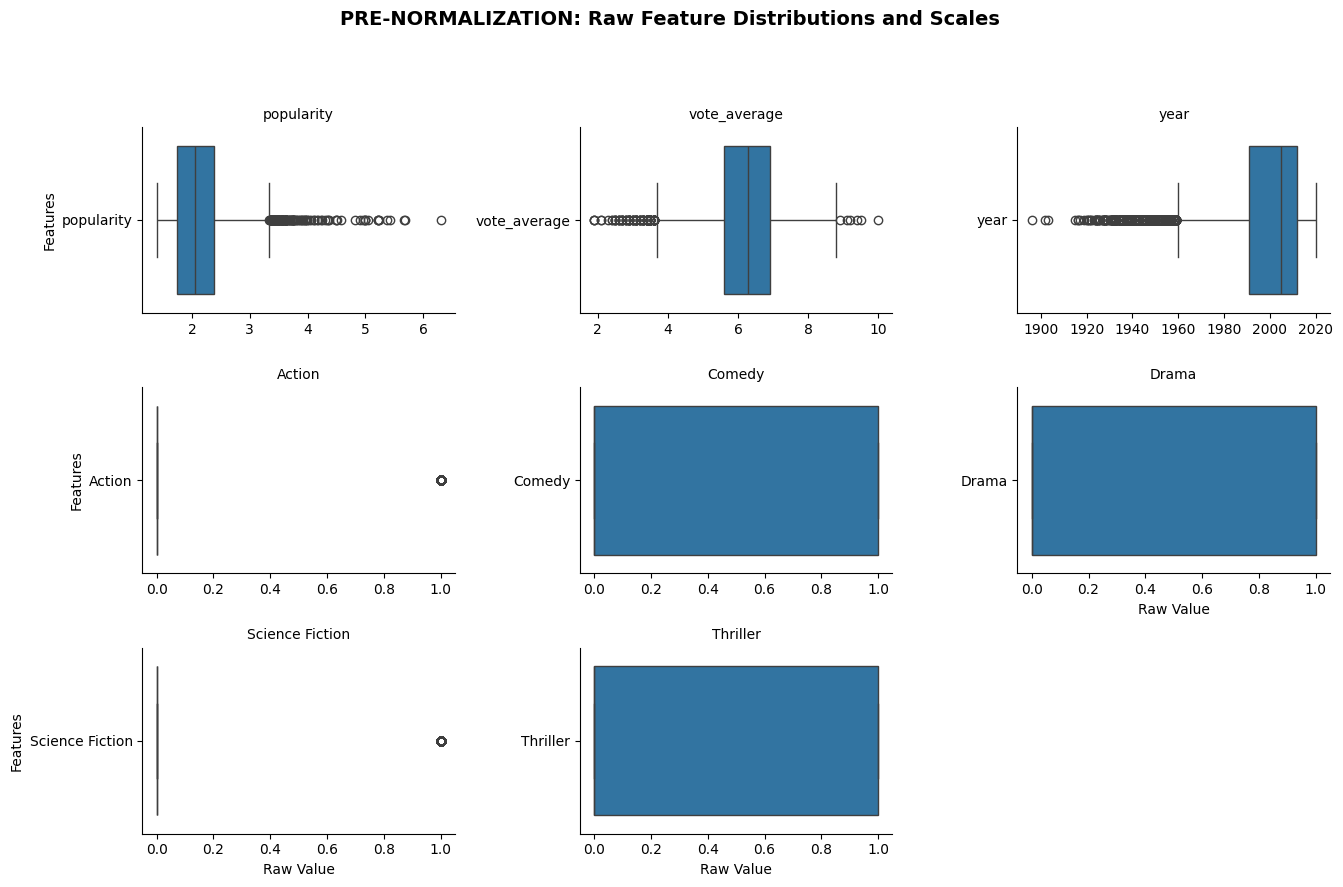

In [36]:
sample_genres = ['Action', 'Comedy', 'Drama', 'Science Fiction', 'Thriller']
available_genres = [g for g in sample_genres if g in genres_dummies.columns]

# Combine raw continuous features and raw binary genres into a single temporary DataFrame
df_raw_plot = pd.concat([
    df_knn_features[['popularity', 'vote_average', 'year']], 
    genres_dummies[available_genres]
], axis=1)

# Melt the DataFrame to long-format for subplots generation
df_raw_melted = df_raw_plot.melt(var_name='Features', value_name='Raw Value')

# Initialize a FacetGrid with independent X-axes to prevent scale crushing
g = sns.FacetGrid(
    df_raw_melted, 
    col="Features", 
    col_wrap=3, 
    sharex=False, 
    sharey=False, 
    height=3, 
    aspect=1.5
)

# Map horizontal boxplots onto the grid
g.map(sns.boxplot, 'Raw Value', 'Features', order=None)

# Adjust layouts and titles
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.85, hspace=0.4, wspace=0.4)
g.figure.suptitle('PRE-NORMALIZATION: Raw Feature Distributions and Scales', fontsize=14, fontweight='bold')
plt.show()

In [37]:
# B. Normalization of quantitative metrics (CRITICAL for K-NN)
# Without normalization, metrics like popularity (e.g., 120) will scale 120x heavier than a binary genre (0 or 1)
scaler = MinMaxScaler()
numerical_features = scaler.fit_transform(df_knn_features[['popularity', 'vote_average', 'year']])
df_numerical = pd.DataFrame(numerical_features, columns=['norm_popularity', 'norm_vote', 'norm_year'])

# C. Final concatenation to construct the structured Feature Matrix
# Join binary genre features with scaled popularity, vote, and year attributes
matrix_structural = pd.concat([genres_dummies, df_numerical], axis=1).values

print(f"Feature Matrix successfully created for K-NN. Shape: {matrix_structural.shape}")

Feature Matrix successfully created for K-NN. Shape: (12801, 23)


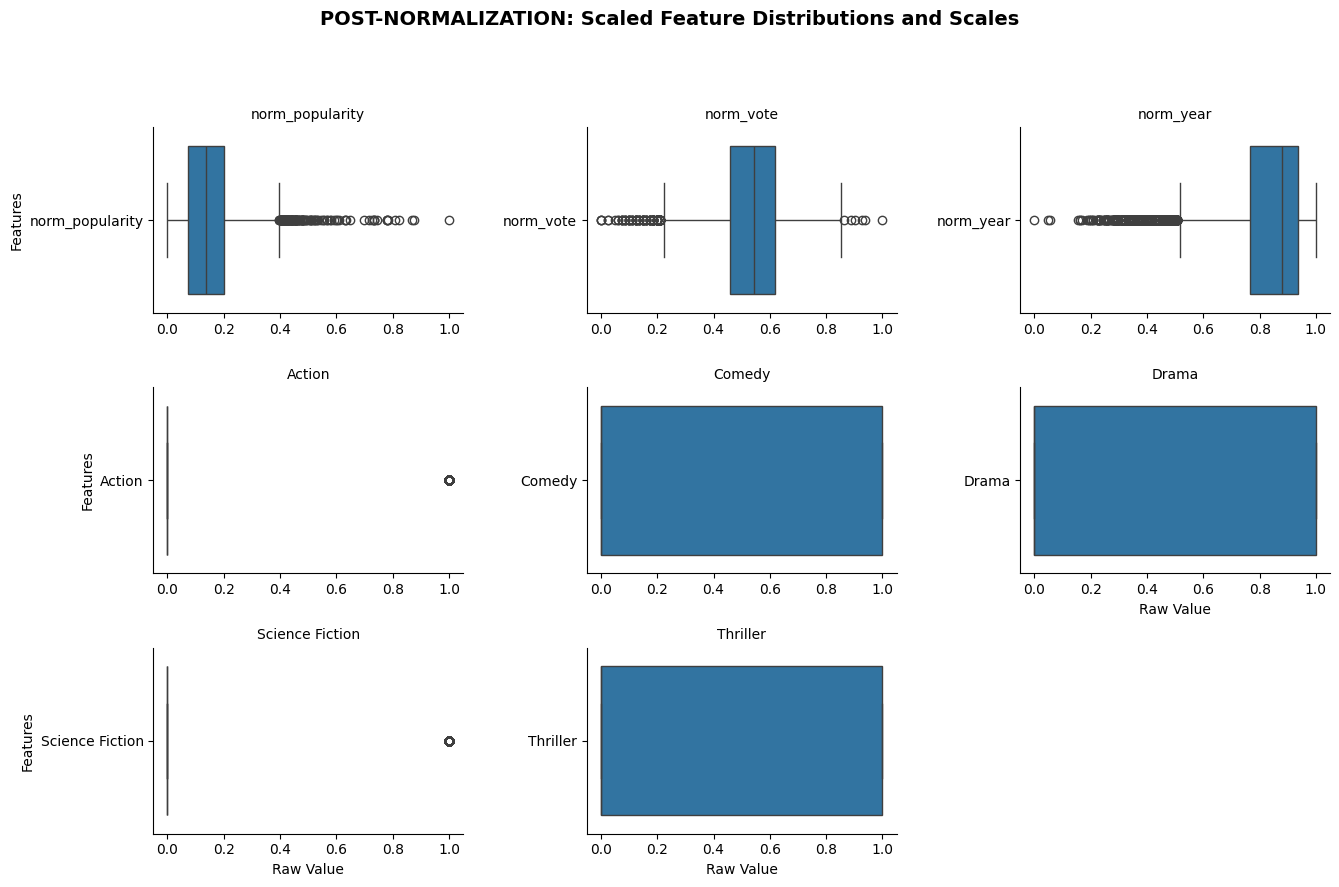

In [39]:
sample_genres = ['Action', 'Comedy', 'Drama', 'Science Fiction', 'Thriller']
available_genres = [g for g in sample_genres if g in genres_dummies.columns]

# Combine raw continuous features and raw binary genres into a single temporary DataFrame
df_raw_plot = pd.concat([
    df_numerical, 
    genres_dummies[available_genres]
], axis=1)

# Melt the DataFrame to long-format for subplots generation
df_raw_melted = df_raw_plot.melt(var_name='Features', value_name='Raw Value')

# Initialize a FacetGrid with independent X-axes to prevent scale crushing
g = sns.FacetGrid(
    df_raw_melted, 
    col="Features", 
    col_wrap=3, 
    sharex=False, 
    sharey=False, 
    height=3, 
    aspect=1.5
)

# Map horizontal boxplots onto the grid
g.map(sns.boxplot, 'Raw Value', 'Features', order=None)

# Adjust layouts and titles
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.85, hspace=0.4, wspace=0.4)
g.figure.suptitle('POST-NORMALIZATION: Scaled Feature Distributions and Scales', fontsize=14, fontweight='bold')
plt.show()

In [40]:
# ========================================================
# 2. K-NN MODEL TRAINING
# ========================================================
print("2. [TRAINING] Fitting K-NN model on structural dummy features...")
# Using Cosine distance as it yields optimal stability over sparse, high-dimensional binary vectors
knn_structural = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='auto')
knn_structural.fit(matrix_structural)

# ========================================================
# 3. QUERY: SEED DEPLOYMENT (Your 5-star & liked movies)
# ========================================================
favourites = df_profile_mapped[(df_profile_mapped['Rating'] == 5.0) & (df_profile_mapped['liked'] == True)]
favourites_ids = favourites['tmdb_id'].values

knn_ohe_recommended = []

# Retrieve nearest neighbors for each favorite seed movie
for target_id in favourites_ids:
    if target_id in df_knn_features['tmdb_id'].values:
        global_idx = df_knn_features[df_knn_features['tmdb_id'] == target_id].index[0]
        film_emb = matrix_structural[global_idx].reshape(1, -1)
        
        distances, idx_closed_films = knn_structural.kneighbors(film_emb)
        
        # Skip the first element (index 0) since it is a self-match with the seed movie itself
        for i in range(1, len(idx_closed_films[0])):
            idx_closed_film = idx_closed_films[0][i]
            distance = distances[0][i]
            
            founded = df_knowledge_base.iloc[idx_closed_film].copy()
            founded['distance'] = distance
            founded['recommended_by'] = df_knowledge_base.iloc[global_idx]['title']
            knn_ohe_recommended.append(founded)

# ========================================================
# 4. POST-PROCESSING AND RANKING CRITERIA (TOP 10)
# ========================================================
df_output_knn = pd.DataFrame(knn_ohe_recommended)

# Exclude already watched movies to ensure novelty
seen = df_profile_mapped['tmdb_id'].values
df_output_knn = df_output_knn[~df_output_knn['tmdb_id'].isin(seen)]

df_output_knn = df_output_knn.sort_values(by='distance', ascending=True)
top_10_approach_1 = df_output_knn.drop_duplicates(subset=['tmdb_id'], keep='first').head(10)

print("\n===============================================================")
print("                STRUCTURAL K-NN DUMMIES TOP 10           ")
print("===============================================================\n")
for i, row in top_10_approach_1.reset_index().iterrows():
    print(f"{i+1}. {row['title']} ({int(row['year'])}) - Distance: {row['distance']:.2e}")
    print(f"   Recommended based on structural/categorical correlation with: '{row['recommended_by']}'")
    print("-" * 63)

2. [TRAINING] Fitting K-NN model on structural dummy features...

                STRUCTURAL K-NN DUMMIES TOP 10           

1. All Three of Us (2015) - Distance: 9.28e-06
   Recommended based on structural/categorical correlation with: 'Perfect Strangers'
---------------------------------------------------------------
2. Polisse (2011) - Distance: 3.49e-05
   Recommended based on structural/categorical correlation with: 'The Hunt'
---------------------------------------------------------------
3. A Separation (2011) - Distance: 4.31e-05
   Recommended based on structural/categorical correlation with: 'The Hunt'
---------------------------------------------------------------
4. The Help (2011) - Distance: 1.03e-04
   Recommended based on structural/categorical correlation with: 'The Hunt'
---------------------------------------------------------------
5. Dangal (2016) - Distance: 1.13e-04
   Recommended based on structural/categorical correlation with: 'The Hunt'
----------------------

We can notice how small and compressed the resulting distances are. While this behavior might initially be attributed to the curse of dimensionality, 23 dimensions are mathematically too few to cause a geometric collapse of variance, especially since Cosine Similarity was chosen as the metric. Instead, the root cause lies in the architectural structure of One-Hot Encoding.By transforming categorical genres into sparse binary vectors ($0$ or $1$), we project the movies into a rigid, orthogonal ipercube. In this discrete space, there are no continuous topological transitions; the model treats the distance between highly related genres (e.g., Action and Adventure) as identical to the distance between completely unrelated ones (e.g., Action and Documentary). This lack of semantic fluidity, combined with the fact that the 20 binary genre columns completely overwhelm the 3 continuous metrics in distance calculations, forces the spatial points into tight, artificial clusters, resulting in highly compressed and poorly differentiated similarity distances.

In [41]:
# ========================================================
# 5. EVALUATION CALL (Centralized Metric Engine)
# ========================================================

knn_metrics = evaluate_recommender_system(knn_ohe_recommended, df_profile_mapped, model_name="Structural K-NN")


       KDD EVALUATION REPORT: STRUCTURAL K-NN       
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted User History Nodes (Hits): 41
-> Liked-Based Hit Rate:                  17.07%
-> 5-Star Perfect Hit Rate:               29.27%
-> Intercepted History Mean Rating:       4.29/5.00
-> SYSTEM PERFORMANCE SCORE:              44.59 Pts



##### Space Analysis

[DIAGNOSTICS] Computing Pairwise Euclidean Distances...


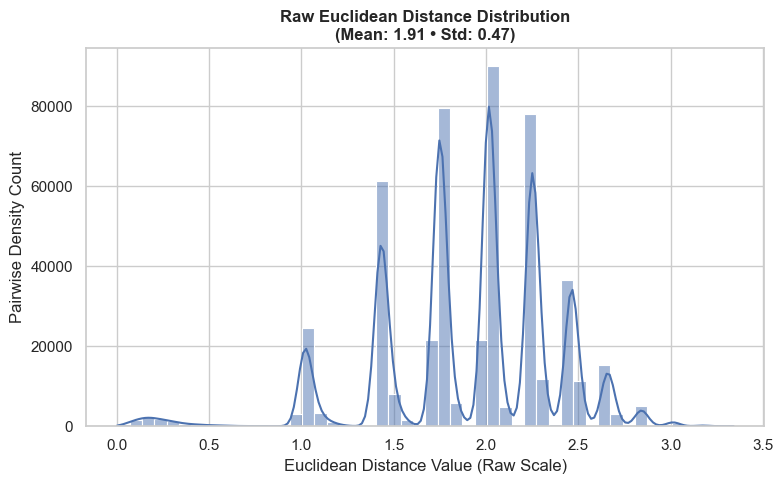

In [42]:
# =====================================================================
# DIAGNOSTICS: EUCLIDEAN DISTANCE PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Euclidean Distances...")

# 1. Isolate the final integrated matrix (20 Genres + Popularity, Year, Rating)
# Ensure data normalization is applied to preserve feature domain equilibrium
np.random.seed(42)
sample_idx = np.random.choice(matrix_structural.shape[0], size=min(1000, matrix_structural.shape[0]), replace=False)
matrix_sample = matrix_structural[sample_idx]

# Compute Euclidean Distance on Raw Data
euclidean_raw = euclidean_distances(matrix_sample)
# Extract unique pairs from the upper triangle to avoid duplication
raw_flat = euclidean_raw[np.triu_indices_from(euclidean_raw, k=1)]

# 2. PLOT THE DISTRIBUTIONS
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Raw Euclidean Plot
sns.histplot(raw_flat, bins=50, kde=True, color='#4C72B0', edgecolor='white')
plt.title(f'Raw Euclidean Distance Distribution\n(Mean: {np.mean(raw_flat):.2f} • Std: {np.std(raw_flat):.2f})', fontweight='bold')
plt.xlabel('Euclidean Distance Value (Raw Scale)')
plt.ylabel('Pairwise Density Count')

plt.tight_layout()
plt.show()

The pairwise Raw Euclidean Distance Distribution under the uncompressed one-hot encoding configuration completely breaks away from continuous topologies, manifesting as a highly discrete, multi-modal "comb" distribution. Instead of smooth distance variations, the catalog is locked into rigid, mathematical steps:
- *The Sparsity Peaks* (The "Comb" Teeth at $1.0, 1.41, 1.73, 2.0, 2.23$): Because the 20 genre columns are purely binary ($0$ or $1$) and orthogonal, the Euclidean distance between any two movies' genre profiles can only equal discrete square roots of integers ($\sqrt{1}=1.0$, $\sqrt{2}\approx1.41$, $\sqrt{3}\approx1.73$, $\sqrt{4}=2.0$, and so on). Each peak represents pairs of movies that differ by exactly 1, 2, 3, or 4 genres. The minor continuous smearing around these sharp teeth is exclusively the work of the 3 scaled quantitative metrics (popularity, year, rating).
- *The Intra-Genre Subspace* ($0.0 - 0.4$): The tiny, flattened curve on the far left captures movies that share the exact same combination of genres. Within this small pool, the distance is entirely driven by the continuous attributes.
- *The Structural Curse of Sparsity*: This plot beautifully exposes the geometric rigidity of raw one-hot encoding. For a K-NN classifier, millions of movie pairs are clumped together at identical distance tiers (e.g., over 100,000 pairs sit exactly at a distance of $2.0$). This lacks the mathematical granularity needed to establish subtle, nuanced ranking order, proving that raw one-hot encoding forces the distance estimator to make very crude geometric compromises.

[DIAGNOSTICS] Computing Pairwise Cosine Metrics...


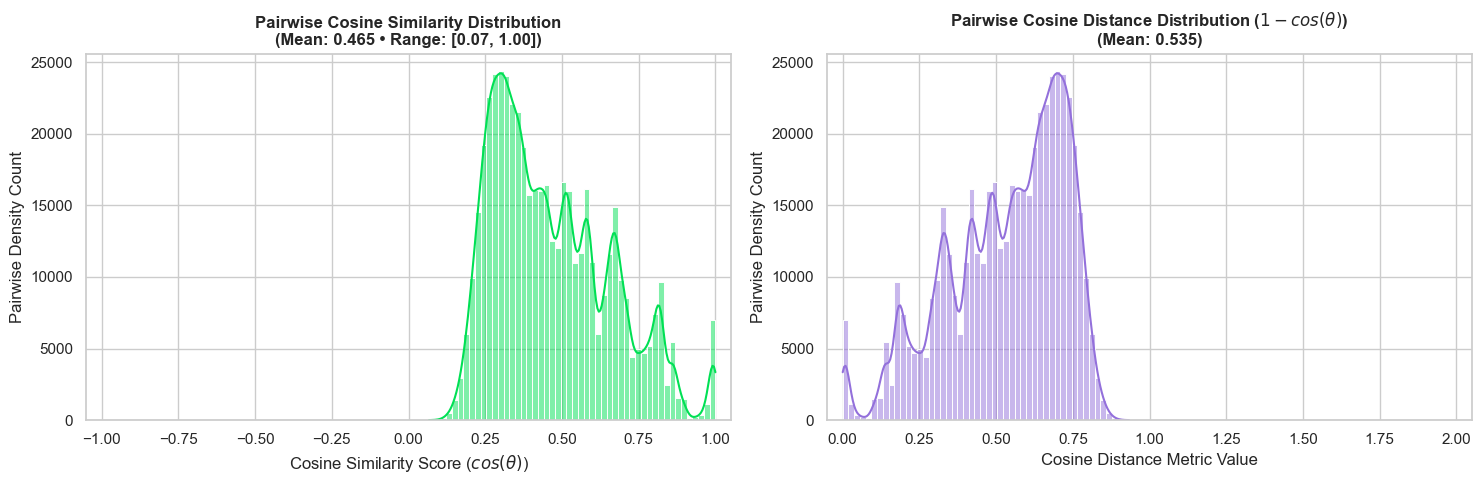

In [43]:
# =====================================================================
# DIAGNOSTICS: COSINE METRIC PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Cosine Metrics...")

# Extract unique pairs using the exact same sample window for directional evaluation
np.random.seed(42)
sample_idx = np.random.choice(matrix_structural.shape[0], size=min(1000, matrix_structural.shape[0]), replace=False)
cos_sim_matrix = cosine_similarity(matrix_structural[sample_idx])

# Extract unique pairs from the upper triangle  
sim_flat = cos_sim_matrix[np.triu_indices_from(cos_sim_matrix, k=1)]
# Compute the complementary Cosine Distance: Distance = 1 - Similarity
dist_flat = 1.0 - sim_flat

# 2. PLOT THE DISTRIBUTIONS SIDE-BY-SIDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Cosine Similarity Plot (Angular proximity)
sns.histplot(sim_flat, bins=50, kde=True, ax=ax1, color='#00E054', edgecolor='white')
ax1.set_title(f'Pairwise Cosine Similarity Distribution\n(Mean: {np.mean(sim_flat):.3f} • Range: [{np.min(sim_flat):.2f}, {np.max(sim_flat):.2f}])', fontweight='bold')
ax1.set_xlabel('Cosine Similarity Score ($cos(\\theta)$)')
ax1.set_ylabel('Pairwise Density Count')
ax1.set_xlim(-1.05, 1.05) 

# Cosine Distance Plot (Angular diversity utilized by K-NN)
sns.histplot(dist_flat, bins=50, kde=True, ax=ax2, color='#9370DB', edgecolor='white')
ax2.set_title(f'Pairwise Cosine Distance Distribution ($1 - cos(\\theta)$)\n(Mean: {np.mean(dist_flat):.3f})', fontweight='bold')
ax2.set_xlabel('Cosine Distance Metric Value')
ax2.set_ylabel('Pairwise Density Count')
ax2.set_xlim(-0.05, 2.05) 

plt.tight_layout()
plt.show()

The One-Hot Cosine Metric Plots mirror this discrete rigidity, providing an empirical look at the "combinatorial overlap" of keywords across the catalog.
- *The Multi-Peak Jagged Mass* (Similarity $+0.20$ to $+0.85$): Instead of a clean Gaussian shape, the similarity distribution looks like a series of waves. These ripples correspond mathematically to the exact ratios of shared genres divided by the product of the vector lengths. Because a movie cannot have "half a genre," the directional angles are trapped in a finite set of combinations, creating a choppy, step-like landscape.
- *The Zero-Overlap Limit* ($+0.07$): The distribution abruptly drops off near $+0.07$ similarity ($0.93$ distance). In a pure one-hot space, two movies with completely different genres would hit an absolute orthogonal zero ($0.0$). The fact that the curve bottoms out at $+0.07$ means that the 3 continuous features are the only elements keeping totally different movies from being perfectly perpendicular.The Identity Spike ($+1.00$): The narrow spike at $+1.00$ similarity (and $0.00$ distance) represents perfect genre-profile matches, where the K-NN is forced to rely solely on continuous signals for sub-ranking.

### Dimensionality Reduction using PCA

1. [PCA ANALYSIS] Computing cumulative explained variance across all dimensions...
-> Total components evaluated: 23
--> SUCCESS: 13 components are required to retain 90.0% of global variance.
--> SUCCESS: 16 components are required to retain 95.0% of global variance.

2. [VISUALIZATION] Plotting Scree Plot with Cumulative Variance Threshold...


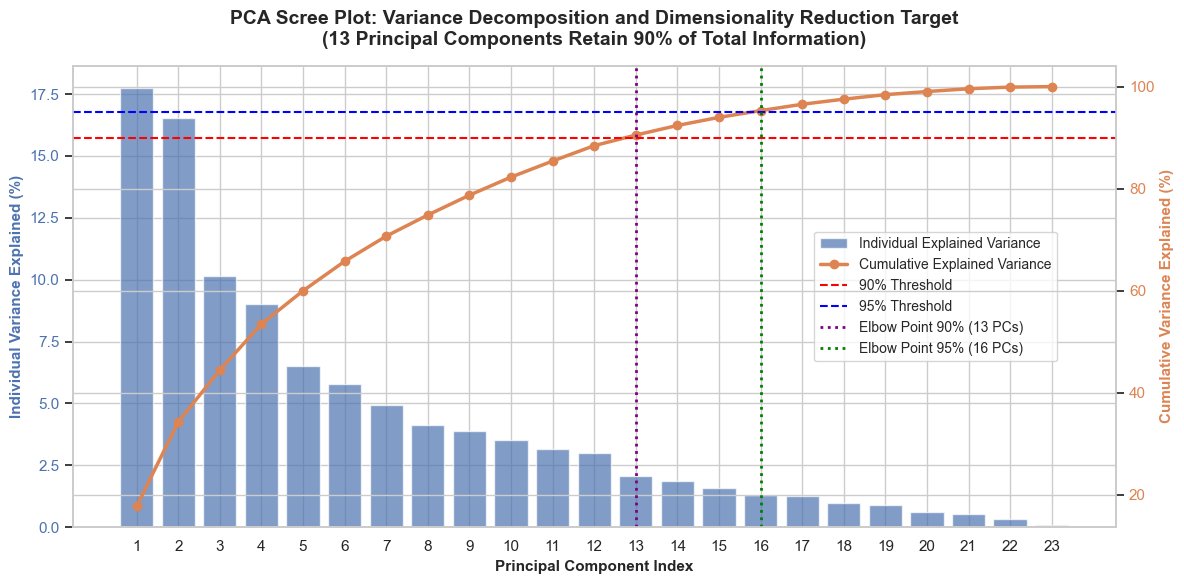

In [44]:
# =====================================================================
# ADVANCED KDD STEP: CUMULATIVE PCA VARIANCE & SCREE PLOT
# =====================================================================
print("1. [PCA ANALYSIS] Computing cumulative explained variance across all dimensions...")

pca_full = PCA(random_state=42)
pca_full.fit(matrix_structural)

variance_proportions = pca_full.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(variance_proportions)

THRESHOLD_1 = 90.0
THRESHOLD_2 = 95.0
n_components_needed_1 = np.argmax(cumulative_variance >= THRESHOLD_1) + 1
n_components_needed_2 = np.argmax(cumulative_variance >= THRESHOLD_2) + 1

print(f"-> Total components evaluated: {len(variance_proportions)}")
print(f"--> SUCCESS: {n_components_needed_1} components are required to retain {THRESHOLD_1}% of global variance.")
print(f"--> SUCCESS: {n_components_needed_2} components are required to retain {THRESHOLD_2}% of global variance.")

# =====================================================================
# 2. RENDER SCREE PLOT WITH CUMULATIVE THRESHOLD
# =====================================================================
print("\n2. [VISUALIZATION] Plotting Scree Plot with Cumulative Variance Threshold...")

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

x_axis = np.arange(1, len(variance_proportions) + 1)

ax1.bar(x_axis, variance_proportions, color='#4C72B0', alpha=0.7, label='Individual Explained Variance')
ax1.set_xlabel('Principal Component Index', fontsize=11, fontweight='bold')
ax1.set_ylabel('Individual Variance Explained (%)', color='#4C72B0', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_xticks(x_axis)

ax2 = ax1.twinx()

ax2.plot(x_axis, cumulative_variance, color='#DD8452', marker='o', linewidth=2.5, label='Cumulative Explained Variance')
ax2.set_ylabel('Cumulative Variance Explained (%)', color='#DD8452', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#DD8452')

ax2.axhline(y=THRESHOLD_1, color='red', linestyle='--', linewidth=1.5, label=f'{int(THRESHOLD_1)}% Threshold')
ax2.axhline(y=THRESHOLD_2, color='blue', linestyle='--', linewidth=1.5, label=f'{int(THRESHOLD_2)}% Threshold')

ax2.axvline(x=n_components_needed_1, color='purple', linestyle=':', linewidth=2, 
            label=f'Elbow Point {int(THRESHOLD_1)}% ({n_components_needed_1} PCs)')
ax2.axvline(x=n_components_needed_2, color='green', linestyle=':', linewidth=2, 
            label=f'Elbow Point {int(THRESHOLD_2)}% ({n_components_needed_2} PCs)')

plt.title(f'PCA Scree Plot: Variance Decomposition and Dimensionality Reduction Target\n({n_components_needed_1} Principal Components Retain {int(THRESHOLD_1)}% of Total Information)', 
          fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', bbox_to_anchor=(0.95, 0.5), fontsize=10)

plt.tight_layout()
plt.show()

The PCA decomposition reveals that 13 principal components are required to retain 90% of the global variance from the baseline feature space. Given this high truncation threshold, substituting clustering with PCA yields negligible dimensional compression (reducing features only from 22 to 13) while introducing a severe deficit in model interpretability.

In a recommendation framework, preserving the semantic identity of the dimensions is operationally vital for user profiling. While PCA constructs abstract, mathematical axes that cannot be translated into intuitive cinematic concepts, Soft Clustering compresses the sparse binary ipercube into a dense set of distinct, human-readable macro-genres. Therefore, the nominal variance preserved by a 13-component PCA does not justify the total loss of model explainability, establishing clustering as the mathematically and conceptually superior choice for our architecture.

### Dimensionality Reduction using K-Means Clustering

#### Hard K-Means

We implement Hard Clustering (K-Means) as a strategic feature aggregation technique to restore structural balance to the distance matrix. In the raw preprocessed matrix, the ratio of continuous variables (Year, Rating, Popularity) to categorical variables (One-Hot Encoded Genres) stands at an asymmetric 3:20. Because distance estimators sum the squared differences across all dimensions, the 20 binary genre columns mathematically overwhelm the 3 continuous metrics, rendering them functionally obsolete. By executing K-Means clustering, we collapse the sparse 20-dimensional genre space into 6 dense latent macro-themes. This scales the structural ratio from a highly distorted 3:20 down to a balanced 3:6, finally allowing public quality and historical data to meaningfully influence the K-NN proximity calculations.

In [45]:
print("1. [FEATURE EXTRACTION] Compressing genre features via Hard K-Means...")

# 1. Isolate structural attributes and build the high-dimensional genre dummy matrix
df_cluster_features = df_knowledge_base[['tmdb_id', 'title', 'year', 'genres', 'popularity', 'vote_average']].copy()
genres_dummies = df_cluster_features['genres'].fillna('').astype(str).str.split(', ').str.join('|').str.get_dummies()

# 2. Train Hard K-Means on the dummy matrix to group correlated categories into macro-clusters
N_CLUSTER_GENRES = 6
kmeans_genres = KMeans(n_clusters=N_CLUSTER_GENRES, random_state=42, n_init=10)
cluster_labels = kmeans_genres.fit_predict(genres_dummies)

# 3. Create the compressed categorical DataFrame via One-Hot Encoding of hard cluster assignments
df_compressed_genres = pd.get_dummies(cluster_labels, prefix='macro_genre_cluster').astype(int)

1. [FEATURE EXTRACTION] Compressing genre features via Hard K-Means...


In [46]:
print("1. [INTERPRETATION] Extracting structural genre-to-cluster alignments...")

centroids = kmeans_genres.cluster_centers_

df_centroids = pd.DataFrame(
    centroids.T, 
    index=genres_dummies.columns, 
    columns=[f'cluster_{i}' for i in range(N_CLUSTER_GENRES)]
)

# Exclusive Association
# Get index of the most dominant cluster in each genre
dominant_cluster_per_genre = df_centroids.idxmax(axis=1)

# Initialize matrix filled with 0s
df_hard_mapping = pd.DataFrame(
    0, 
    index=genres_dummies.columns, 
    columns=[f'cluster_{i}' for i in range(N_CLUSTER_GENRES)]
)

for genre, dominant_cluster in dominant_cluster_per_genre.items():
    df_hard_mapping.loc[genre, dominant_cluster] = 1

# ===============================================================
# KDD UPDATE: APPEND TOTAL GENRE COUNTS PER CLUSTER
# ===============================================================
# Compute the vertical sum to aggregate how many genres fall into each cluster
cluster_totals = df_hard_mapping.sum(axis=0)

# Append the totals as a new row at the bottom of the mapping DataFrame
df_hard_mapping.loc['TOTAL_ASSIGNED_GENRES'] = cluster_totals

print("\n===============================================================")
print("          GENRE-TO-CLUSTER HARD MAPPING MATRIX                ")
print("===============================================================\n")
print(df_hard_mapping)

1. [INTERPRETATION] Extracting structural genre-to-cluster alignments...

          GENRE-TO-CLUSTER HARD MAPPING MATRIX                

                       cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  \
Action                         0          0          0          0          1   
Adventure                      0          0          0          0          1   
Animation                      1          0          0          0          0   
Comedy                         0          0          1          0          0   
Crime                          0          1          0          0          0   
Documentary                    0          0          0          1          0   
Drama                          0          0          0          1          0   
Family                         1          0          0          0          0   
Fantasy                        1          0          0          0          0   
Foreign                        0          0          0        

##### Optimal $k$ Choice


[DIAGNOSTICS] Initializing Elbow Method and Silhouette Analysis...


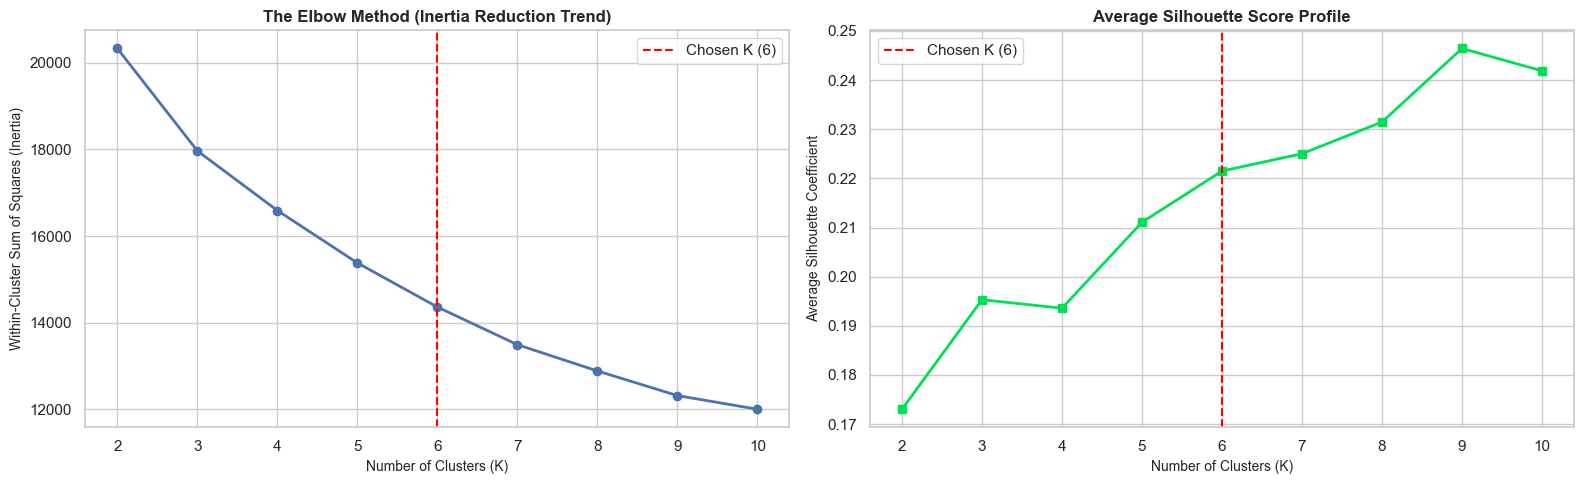


[DIAGNOSTICS] Rendering Silhouette Silhouette Profile for K=6...


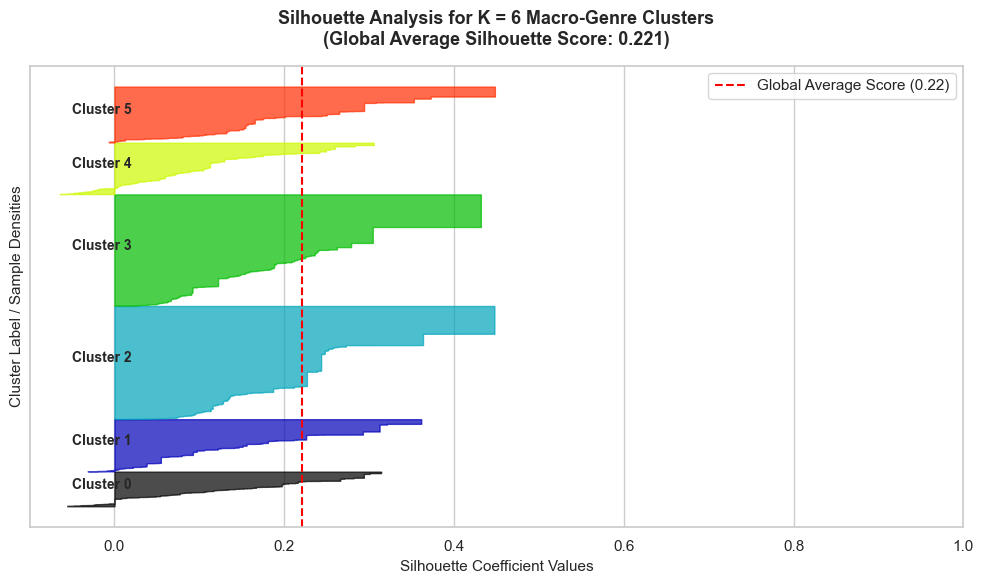

In [47]:
# =====================================================================
# ADVANCED KDD STEP: CLUSTERING OPTIMIZATION & DIAGNOSTICS
# =====================================================================
print("\n[DIAGNOSTICS] Initializing Elbow Method and Silhouette Analysis...")

# 1. COMPUTE METRICS ACROSS A RANGE OF CLUSTERS (K = 2 to 10)
k_range = range(2, 11)
inertias = []
silhouette_avgs = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(genres_dummies)
    
    inertias.append(km.inertia_)
    silhouette_avgs.append(silhouette_score(genres_dummies, labels))

# ---------------------------------------------------------------------
# PLOT 1: PLOTTING ELBOW METHOD & SILHOUETTE TRENDS SIDE-BY-SIDE
# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.set_theme(style="whitegrid")

# Elbow Curve (Inertia)
ax1.plot(k_range, inertias, marker='o', color='#4C72B0', linewidth=2)
ax1.axvline(x=N_CLUSTER_GENRES, color='red', linestyle='--', label=f'Chosen K ({N_CLUSTER_GENRES})')
ax1.set_title('The Elbow Method (Inertia Reduction Trend)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)', fontsize=10)
ax1.set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=10)
ax1.legend()

# Silhouette Line Plot
ax2.plot(k_range, silhouette_avgs, marker='s', color='#00E054', linewidth=2)
ax2.axvline(x=N_CLUSTER_GENRES, color='red', linestyle='--', label=f'Chosen K ({N_CLUSTER_GENRES})')
ax2.set_title('Average Silhouette Score Profile', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)', fontsize=10)
ax2.set_ylabel('Average Silhouette Coefficient', fontsize=10)
ax2.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# PLOT 2: DETAILED SILHOUETTE PROFILE FOR SELECTED N_CLUSTER_GENRES (K=6)
# ---------------------------------------------------------------------
print(f"\n[DIAGNOSTICS] Rendering Silhouette Silhouette Profile for K={N_CLUSTER_GENRES}...")

fig, ax = plt.subplots(figsize=(10, 6))

# Re-run target model to isolate samples coefficients
target_km = KMeans(n_clusters=N_CLUSTER_GENRES, random_state=42, n_init=10)
target_labels = target_km.fit_predict(genres_dummies)
target_silhouette_avg = silhouette_score(genres_dummies, target_labels)
sample_silhouette_values = silhouette_samples(genres_dummies, target_labels)

y_lower = 10
for i in range(N_CLUSTER_GENRES):
    # Aggregate and sort coefficients for samples belonging to the current cluster i
    ith_cluster_silhouette_values = sample_silhouette_values[target_labels == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / N_CLUSTER_GENRES)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    # Label the silhouette plots with their cluster numbers at the middle
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cluster {i}", fontsize=10, fontweight='bold')
    y_lower = y_upper + 10  # 10 for the gaps between profiles

ax.set_title(f'Silhouette Analysis for K = {N_CLUSTER_GENRES} Macro-Genre Clusters\n'
             f'(Global Average Silhouette Score: {target_silhouette_avg:.3f})', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Silhouette Coefficient Values', fontsize=11)
ax.set_ylabel('Cluster Label / Sample Densities', fontsize=11)

# The vertical line for average silhouette score of all the values
ax.axvline(x=target_silhouette_avg, color="red", linestyle="--", linewidth=1.5, 
           label=f'Global Average Score ({target_silhouette_avg:.2f})')
ax.set_yticks([])  # Clear the y-axis labels
ax.set_xlim([-0.1, 1.0])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

##### Execution

In [50]:
# 4. Normalize continuous continuous variables (Crucial step for distance-based models)
scaler = MinMaxScaler()
numerical_scaled = scaler.fit_transform(df_cluster_features[['popularity', 'vote_average', 'year']])
df_numerical = pd.DataFrame(numerical_scaled, columns=['norm_popularity', 'norm_vote', 'norm_year'])

# 5. Concatenate compressed binary features with continuous distributions
# Search space scales down from 22 parameters to 7 high-variance columns
matrix_compressed = pd.concat([df_compressed_genres, df_numerical], axis=1).values

print("-> Feature space successfully compressed.")
print(f"-> Original dimensional boundaries: {genres_dummies.shape[1] + df_numerical.shape[1]} columns.")
print(f"-> Compressed dimensions via Cluster Feature Selection: {matrix_compressed.shape[1]} columns.")

# ========================================================
# KDD STEP: DATA MINING (K-NN ON COMPRESSED MATRIX)
# ========================================================
print("\n2. [TRAINING] Fitting pure K-NN engine on compressed matrix space...")

# A dense, low-dimensional space restores mathematical variance to Euclidean distances
knn_pure = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='auto')
knn_pure.fit(matrix_compressed)

# Anchor search queries onto your historical 5-star user nodes
user_seed_movies = df_profile_mapped[(df_profile_mapped['Rating'] == 5.0) & (df_profile_mapped['liked'] == True)]
user_seed_ids = user_seed_movies['tmdb_id'].values

knn_hard_cluster_recommended = []

for target_id in user_seed_ids:
    if target_id in df_cluster_features['tmdb_id'].values:
        global_idx = df_cluster_features[df_cluster_features['tmdb_id'] == target_id].index[0]
        query_vector = matrix_compressed[global_idx].reshape(1, -1)
        
        distances, neighbor_indices = knn_pure.kneighbors(query_vector)
        
        # Discard self-match index 0
        for i in range(1, len(neighbor_indices[0])):
            neighbor_idx = neighbor_indices[0][i]
            spatial_distance = distances[0][i]
            
            candidate_item = df_knowledge_base.iloc[neighbor_idx].copy()
            candidate_item['distance'] = spatial_distance
            candidate_item['recommended_by'] = df_knowledge_base.iloc[global_idx]['title']
            knn_hard_cluster_recommended.append(candidate_item)

# ========================================================
# POST-PROCESSING AND RANKING EXECUTION (TOP 10)
# ========================================================
df_output_knn = pd.DataFrame(knn_hard_cluster_recommended)

# Remove previously consumed interactions to ensure novelty
consumed_history_ids = df_profile_mapped['tmdb_id'].values
df_output_knn = df_output_knn[~df_output_knn['tmdb_id'].isin(consumed_history_ids)]

# Order candidates by minimal distance metrics and drop duplicate items
df_output_knn = df_output_knn.sort_values(by='distance', ascending=True)
top_10_approach_1 = df_output_knn.drop_duplicates(subset=['tmdb_id'], keep='first').head(10)

print("\n===============================================================")
print("       K-NN WITH HARD K-MEANS MODEL RANKING (TOP 10)  ")
print("===============================================================\n")
for idx, row in top_10_approach_1.reset_index().iterrows():
    print(f"{idx+1}. {row['title']} ({int(row['year'])}) - Distance: {row['distance']:.2e}")
    print(f"   Recommended via structural alignment with: '{row['recommended_by']}'")
    print("-" * 63)

-> Feature space successfully compressed.
-> Original dimensional boundaries: 23 columns.
-> Compressed dimensions via Cluster Feature Selection: 9 columns.

2. [TRAINING] Fitting pure K-NN engine on compressed matrix space...

       K-NN WITH HARD K-MEANS MODEL RANKING (TOP 10)  

1. All Three of Us (2015) - Distance: 1.14e-05
   Recommended via structural alignment with: 'Perfect Strangers'
---------------------------------------------------------------
2. Coach Carter (2005) - Distance: 1.56e-05
   Recommended via structural alignment with: 'The Machinist'
---------------------------------------------------------------
3. Frankenweenie (2012) - Distance: 1.61e-05
   Recommended via structural alignment with: 'Rango'
---------------------------------------------------------------
4. Head-On (2004) - Distance: 1.72e-05
   Recommended via structural alignment with: 'The Machinist'
---------------------------------------------------------------
5. Colorful (2010) - Distance: 1.93e-05
 

In [52]:
# ========================================================
# EVALUATION CALL (Centralized Metric Engine)
# ========================================================

knn_hard_cluster_metrics = evaluate_recommender_system(knn_hard_cluster_recommended, df_profile_mapped, model_name="Hard K-Means K-NN")


       KDD EVALUATION REPORT: HARD K-MEANS K-NN       
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted User History Nodes (Hits): 53
-> Liked-Based Hit Rate:                  24.53%
-> 5-Star Perfect Hit Rate:               47.17%
-> Intercepted History Mean Rating:       4.50/5.00
-> SYSTEM PERFORMANCE SCORE:              50.72 Pts



##### Space Analysis

[DIAGNOSTICS] Computing Pairwise Euclidean Distances...


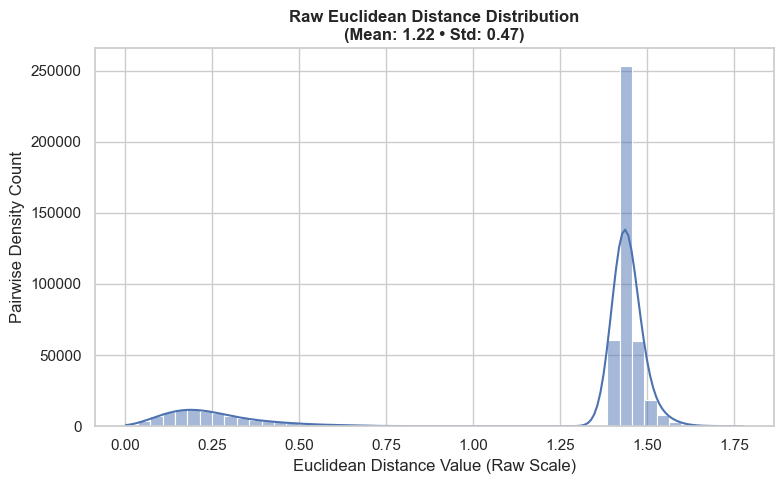

In [53]:
# =====================================================================
# DIAGNOSTICS: EUCLIDEAN DISTANCE PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Euclidean Distances...")

# 1. Isolate the final integrated matrix (6 Hard Clusters + Popularity, Year, Rating)
# Ensure data normalization is applied to preserve feature domain equilibrium
np.random.seed(42)
sample_idx = np.random.choice(matrix_compressed.shape[0], size=min(1000, matrix_compressed.shape[0]), replace=False)
matrix_sample = matrix_compressed[sample_idx]

# Compute Euclidean Distance on Raw Data
euclidean_raw = euclidean_distances(matrix_sample)
# Extract unique pairs from the upper triangle to avoid duplication
raw_flat = euclidean_raw[np.triu_indices_from(euclidean_raw, k=1)]

# 2. PLOT THE DISTRIBUTIONS
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Raw Euclidean Plot
sns.histplot(raw_flat, bins=50, kde=True, color='#4C72B0', edgecolor='white')
plt.title(f'Raw Euclidean Distance Distribution\n(Mean: {np.mean(raw_flat):.2f} • Std: {np.std(raw_flat):.2f})', fontweight='bold')
plt.xlabel('Euclidean Distance Value (Raw Scale)')
plt.ylabel('Pairwise Density Count')

plt.tight_layout()
plt.show()

When transitioning to a Hard Clustering framework, the pairwise Euclidean distance distribution exhibits an extreme bimodal polarization, turning into what is structurally known as an *isolated cluster topology*. The smooth middle ground observed in continuous spaces completely vanishes, splitting the catalog into two starkly disconnected geometric phenomena:
- *The Intramodular Neighborhood Subspace* ($0.0 - 0.4$): The broad, low-density distribution on the left captures the distances between movies residing within the exact same hard cluster. Because these movies share an identical one-hot cluster assignment, the remaining variance in distance is entirely driven by the 3 scaled quantitative metrics (popularity, year, rating). This establishes a highly specialized local search space for the K-NN classifier.
- *The Massive Intercluster Vacuum & Spike* ($1.43$): The monumental, razor-sharp spike exactly at $\approx 1.43$ represents the distances between movies belonging to different hard clusters. In a rigid one-hot encoded matrix, the distance between two different clusters is a constant mathematical baseline ($\sqrt{1^2 + 1^2} = \sqrt{2} \approx 1.414$). The tiny variations flanking this giant peak are simply the minor perturbations added by the normalized continuous features.
- *The Structural Void* ($0.5 - 1.3$): This massive gap represents an absolute geometric void. There are literally zero item pairs in the entire catalog that sit at a medium distance from one another. This proves that Hard Clustering forces an aggressive, uncompromising separation of categories, which guarantees that inter-cluster noise will never pollute local recommendation pools.

[DIAGNOSTICS] Computing Pairwise Cosine Metrics...


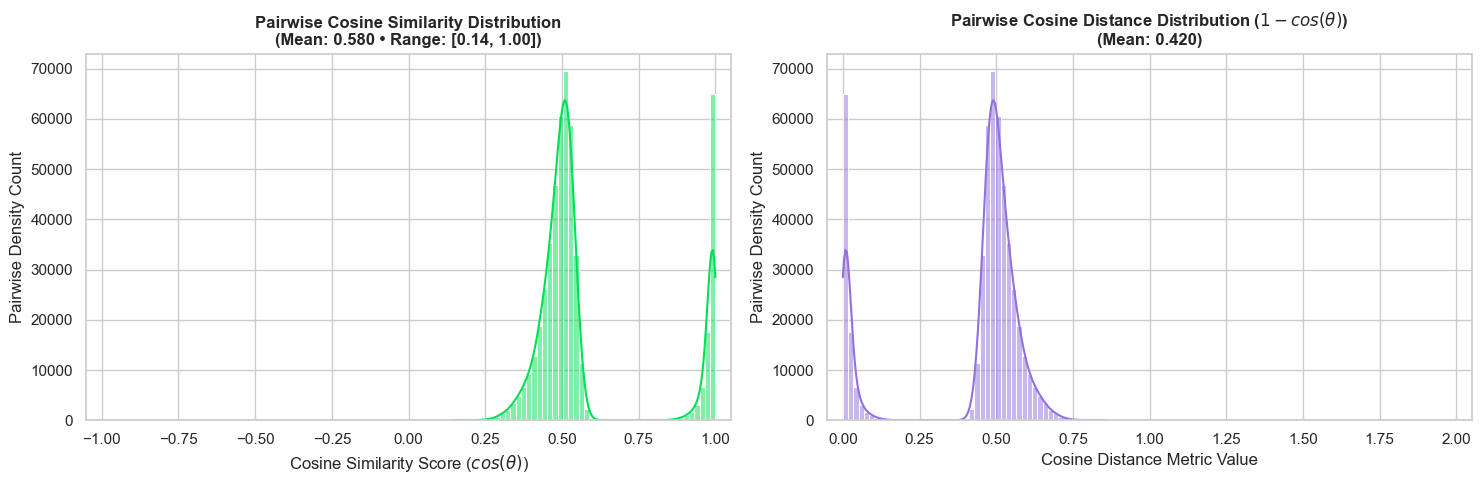

In [54]:
# =====================================================================
# DIAGNOSTICS: COSINE METRIC PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Cosine Metrics...")

# Extract unique pairs using the exact same sample window for directional evaluation
np.random.seed(42)
sample_idx = np.random.choice(matrix_compressed.shape[0], size=min(1000, matrix_compressed.shape[0]), replace=False)
cos_sim_matrix = cosine_similarity(matrix_compressed[sample_idx])

# Extract unique pairs from the upper triangle
sim_flat = cos_sim_matrix[np.triu_indices_from(cos_sim_matrix, k=1)]
# Compute the complementary Cosine Distance: Distance = 1 - Similarity
dist_flat = 1.0 - sim_flat

# 2. PLOT THE DISTRIBUTIONS SIDE-BY-SIDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Cosine Similarity Plot (Angular proximity)
sns.histplot(sim_flat, bins=50, kde=True, ax=ax1, color='#00E054', edgecolor='white')
ax1.set_title(f'Pairwise Cosine Similarity Distribution\n(Mean: {np.mean(sim_flat):.3f} • Range: [{np.min(sim_flat):.2f}, {np.max(sim_flat):.2f}])', fontweight='bold')
ax1.set_xlabel('Cosine Similarity Score ($cos(\\theta)$)')
ax1.set_ylabel('Pairwise Density Count')
ax1.set_xlim(-1.05, 1.05) 

# Cosine Distance Plot (Angular diversity utilized by K-NN)
sns.histplot(dist_flat, bins=50, kde=True, ax=ax2, color='#9370DB', edgecolor='white')
ax2.set_title(f'Pairwise Cosine Distance Distribution ($1 - cos(\\theta)$)\n(Mean: {np.mean(dist_flat):.3f})', fontweight='bold')
ax2.set_xlabel('Cosine Distance Metric Value')
ax2.set_ylabel('Pairwise Density Count')
ax2.set_xlim(-0.05, 2.05) 

plt.tight_layout()
plt.show()

The angular geometry shown in the Hard Cosine Metric Plots mirrors this stark structural division perfectly, highlighting the mathematical constraints of a discrete categorical domain.
- *The Orthogonal Baseline Peak* ($+0.50$ Similarity / $0.50$ Distance): The primary Gaussian distribution is centered precisely at $+0.50$ Cosine Similarity (matching the $0.50$ Cosine Distance peak on the right). This is the exact signature of cross-cluster comparison in a balanced, low-dimensional hard-mapped space. Because the categorical attributes are perfectly orthogonal ($cos(\theta)=0$ between different clusters), the remaining $+0.50$ directional alignment is entirely sustained by the shared global baselines of the scaled continuous data.
- *The Extreme Identity Spike* ($+1.00$ Similarity / $0.00$ Distance): The isolated, dense spike at $+1.00$ similarity (and $0.00$ distance) represents intra-cluster pairings where the categorical vectors match perfectly.
- *The Structural Gap* ($0.60 - 0.90$): Just like the Euclidean space, the angular space shows a total structural breakdown between $+0.60$ and $+0.90$ similarity. A movie is either directionally distinct (residing in the $+0.50$ inter-cluster mass) or directionally identical (the $+1.00$ intra-cluster spike).

#### Soft K-Means

Complementing this dimensionality adjustment, we leverage Soft Clustering (Fuzzy/Probabilistic Clustering) to fundamentally alter the geometric nature of our data. Rather than forcing a movie into a strict, single-category boundary, soft clustering calculates a continuous membership vector across all discovered clusters. This transitions our data topology from rigid, discrete binary values ($0$ or $1$) to continuous affinity probabilities (ranging from $0.0$ to $1.0$). Moving from a discrete to a continuous space eliminates the artificial orthogonality of the One-Hot ipercube, introducing semantic fluidity where the model can now compute smooth, fine-grained distance transitions based on the degree of thematic overlap between films.

In [55]:
print("1. [FEATURE EXTRACTION] Compressing genre features via Soft K-Means...")

# 1. Isolate structural attributes and build the high-dimensional genre dummy matrix
df_cluster_features = df_knowledge_base[['tmdb_id', 'title', 'year', 'genres', 'popularity', 'vote_average']].copy()
genres_dummies = df_cluster_features['genres'].fillna('').astype(str).str.split(', ').str.join('|').str.get_dummies()

# 2. Train the base K-Means model to discover the centroids
N_CLUSTER_GENRES = 6
soft_kmeans_genres = KMeans(n_clusters=N_CLUSTER_GENRES, random_state=42, n_init=10)
soft_kmeans_genres.fit(genres_dummies)

# 3. ADVANCED UPDATE: Compute exact Euclidean distances from all 5 centroids
genre_centroid_distances = soft_kmeans_genres.transform(genres_dummies)

# 4. ADVANCED UPDATE: Apply Thermalized Vector-wise Softmax to get non-exclusive soft assignments
TEMPERATURE = 0.15
negative_distances_scaled = -genre_centroid_distances / TEMPERATURE
exponential_weights = np.exp(negative_distances_scaled - np.max(negative_distances_scaled, axis=1, keepdims=True))
soft_cluster_probabilities = exponential_weights / np.sum(exponential_weights, axis=1, keepdims=True)

# Create the new soft-encoded features DataFrame (Continuous probabilities instead of hard 0 or 1)
df_soft_genres = pd.DataFrame(
    soft_cluster_probabilities, 
    columns=[f'macro_genre_affinity_{i}' for i in range(N_CLUSTER_GENRES)]
).reset_index(drop=True)

1. [FEATURE EXTRACTION] Compressing genre features via Soft K-Means...



2. [VISUALIZATION] Mapping genre distributions via unified pie charts...


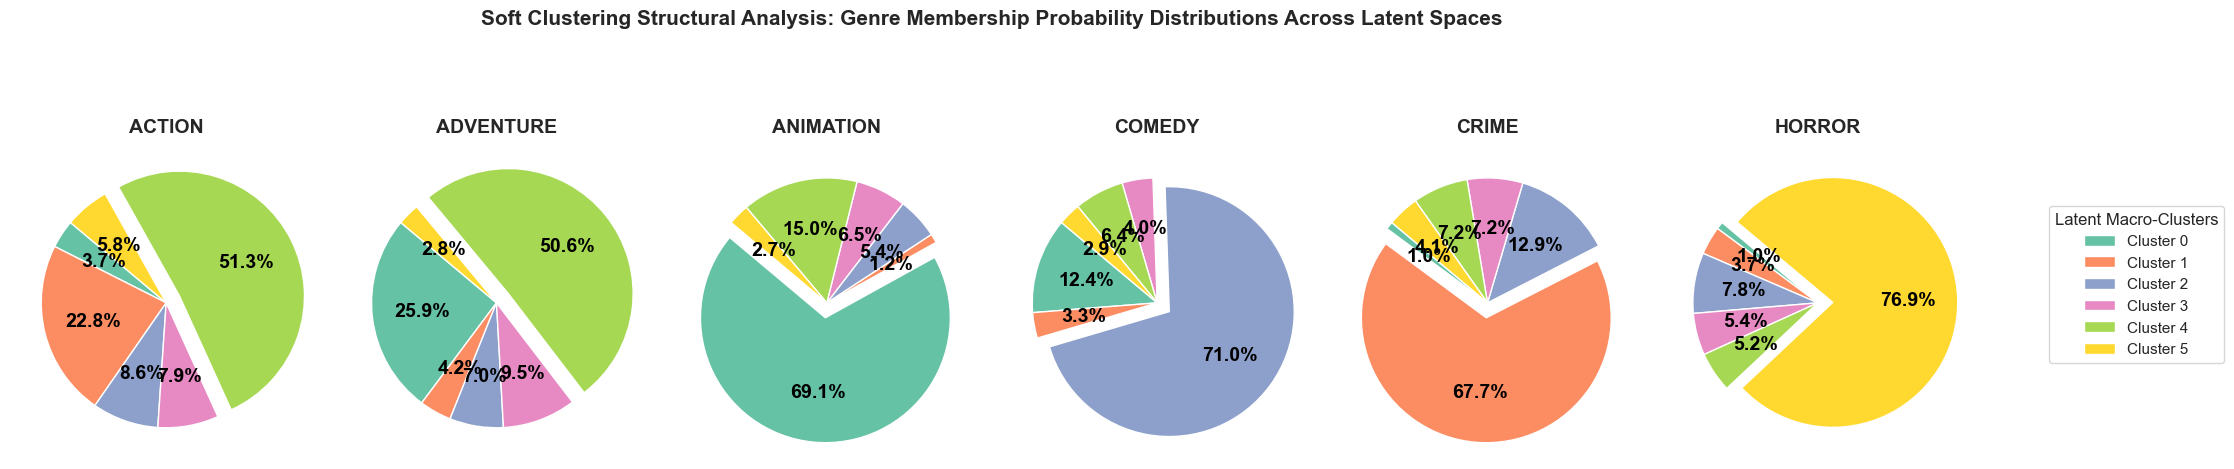

In [56]:
print("\n2. [VISUALIZATION] Mapping genre distributions via unified pie charts...")

# Set a professional palette for the 5 macro-clusters
cluster_colors = sns.color_palette("Set2", N_CLUSTER_GENRES)
cluster_labels = [f'Cluster {i}' for i in range(N_CLUSTER_GENRES)]

# Select the first 5 genres to display
target_genres = genres_dummies.columns[:5].tolist() + genres_dummies.columns[11:12].tolist()

# Initialize a clean grid layout (1 row, 5 columns)
fig, axes = plt.subplots(1, len(target_genres), figsize=(20, 5))

for idx, genre in enumerate(target_genres):
    # Find the indices of movies that belong to the current genre
    genre_indices = genres_dummies[genres_dummies[genre] == 1].index
    
    # Compute the exact mean affinity weight toward each of the 5 macro-clusters
    mean_affinities = df_soft_genres.iloc[genre_indices].mean().values
    
    # Render the pie chart without labels on the wedges to keep it clean
    wedges, texts, autotexts = axes[idx].pie(
        mean_affinities, 
        labels=None,                 # Removed labels from wedges
        autopct='%1.1f%%', 
        startangle=140, 
        colors=cluster_colors,
        # Explode slightly the dominant cluster to emphasize its structural identity
        explode=[0.12 if i == mean_affinities.argmax() else 0 for i in range(N_CLUSTER_GENRES)]
    )
    
    # TUNING UPGRADE: Drastically increase the font size of the percentages inside the wedges
    for autotext in autotexts:
        autotext.set_fontsize(14)    # Bigger percentage text
        autotext.set_weight('bold')
        autotext.set_color('black')
        
    # Clean, elegant title for each subplot row section
    axes[idx].set_title(genre.upper(), fontsize=14, fontweight='bold', pad=10)

# Add a single unified legend for the entire multi-panel architecture
fig.legend(
    wedges, 
    cluster_labels, 
    title="Latent Macro-Clusters", 
    title_fontsize=12,
    loc="center right", 
    bbox_to_anchor=(1.12, 0.5), # Positions the legend perfectly outside on the right
    fontsize=11
)

# Super-title for the entire academic figure integration
plt.suptitle('Soft Clustering Structural Analysis: Genre Membership Probability Distributions Across Latent Spaces', 
             fontsize=15, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

In [59]:
# 5. Normalize continuous quantitative metrics
scaler = MinMaxScaler()
numerical_scaled = scaler.fit_transform(df_cluster_features[['popularity', 'vote_average', 'year']])
df_numerical = pd.DataFrame(numerical_scaled, columns=['norm_popularity', 'norm_vote', 'norm_year']).reset_index(drop=True)

# 6. ADVANCED UPDATE: Concatenate continuous soft cluster probabilities with continuous metrics
# The feature space remains 9 columns, but now expressions are smooth, rich, and fuzzy
matrix_compressed_soft = pd.concat([df_soft_genres, df_numerical], axis=1).values

print("-> Feature space successfully compressed using Soft Clustering.")
print(f"-> Original dimensional boundaries: {genres_dummies.shape[1] + df_numerical.shape[1]} columns.")
print(f"-> Compressed dimensions via Soft-Max Feature Selection: {matrix_compressed_soft.shape[1]} columns.")

# ========================================================
# KDD STEP: DATA MINING (K-NN ON SOFT COMPRESSED MATRIX)
# ========================================================
print("\n2. [TRAINING] Fitting pure K-NN engine on soft matrix space...")

# We feed the continuous soft matrix to the Euclidean K-NN engine
knn_pure = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='auto')
knn_pure.fit(matrix_compressed_soft)

# Anchor search queries onto your historical 5-star user nodes
user_seed_movies = df_profile_mapped[(df_profile_mapped['Rating'] == 5.0) & (df_profile_mapped['liked'] == True)]
user_seed_ids = user_seed_movies['tmdb_id'].values

knn_soft_cluster_recommended = []

for target_id in user_seed_ids:
    if target_id in df_cluster_features['tmdb_id'].values:
        global_idx = df_cluster_features[df_cluster_features['tmdb_id'] == target_id].index[0]
        query_vector = matrix_compressed_soft[global_idx].reshape(1, -1)
        
        distances, neighbor_indices = knn_pure.kneighbors(query_vector)
        
        # Discard self-match index 0
        for i in range(1, len(neighbor_indices[0])):
            neighbor_idx = neighbor_indices[0][i]
            spatial_distance = distances[0][i]
            
            candidate_item = df_knowledge_base.iloc[neighbor_idx].copy()
            candidate_item['distance'] = spatial_distance
            candidate_item['recommended_by'] = df_knowledge_base.iloc[global_idx]['title']
            knn_soft_cluster_recommended.append(candidate_item)

# ========================================================
# POST-PROCESSING AND RANKING EXECUTION (TOP 10)
# ========================================================
df_output_knn = pd.DataFrame(knn_soft_cluster_recommended)

# Remove previously consumed interactions to ensure novelty
consumed_history_ids = df_profile_mapped['tmdb_id'].values
df_output_knn = df_output_knn[~df_output_knn['tmdb_id'].isin(consumed_history_ids)]

# Order candidates by minimal distance metrics and drop duplicate items
df_output_knn = df_output_knn.sort_values(by='distance', ascending=True)
top_10_approach_1 = df_output_knn.drop_duplicates(subset=['tmdb_id'], keep='first').head(10)

print("\n===============================================================")
print("               PURIFIED SOFT K-NN MODEL RANKING                  ")
print("===============================================================\n")
for idx, row in top_10_approach_1.reset_index().iterrows():
    print(f"{idx+1}. {row['title']} ({int(row['year'])}) - Distance: {row['distance']:.2e}")
    print(f"   Recommended via soft-structural alignment with: '{row['recommended_by']}'")
    print("-" * 63)

-> Feature space successfully compressed using Soft Clustering.
-> Original dimensional boundaries: 23 columns.
-> Compressed dimensions via Soft-Max Feature Selection: 9 columns.

2. [TRAINING] Fitting pure K-NN engine on soft matrix space...

               PURIFIED SOFT K-NN MODEL RANKING                  

1. All Three of Us (2015) - Distance: 1.17e-05
   Recommended via soft-structural alignment with: 'Perfect Strangers'
---------------------------------------------------------------
2. Frankenweenie (2012) - Distance: 2.16e-05
   Recommended via soft-structural alignment with: 'Rango'
---------------------------------------------------------------
3. Polisse (2011) - Distance: 3.50e-05
   Recommended via soft-structural alignment with: 'The Hunt'
---------------------------------------------------------------
4. ParaNorman (2012) - Distance: 3.83e-05
   Recommended via soft-structural alignment with: 'Rango'
---------------------------------------------------------------
5. A Sep

In [60]:
# ========================================================
# EVALUATION CALL (Centralized Metric Engine)
# ========================================================

knn_soft_cluster_metrics = evaluate_recommender_system(knn_soft_cluster_recommended, df_profile_mapped, model_name="Soft K-Means K-NN")


       KDD EVALUATION REPORT: SOFT K-MEANS K-NN       
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted User History Nodes (Hits): 39
-> Liked-Based Hit Rate:                  15.38%
-> 5-Star Perfect Hit Rate:               35.90%
-> Intercepted History Mean Rating:       4.28/5.00
-> SYSTEM PERFORMANCE SCORE:              43.49 Pts



##### Space Analysis

[DIAGNOSTICS] Computing Pairwise Euclidean Distances...


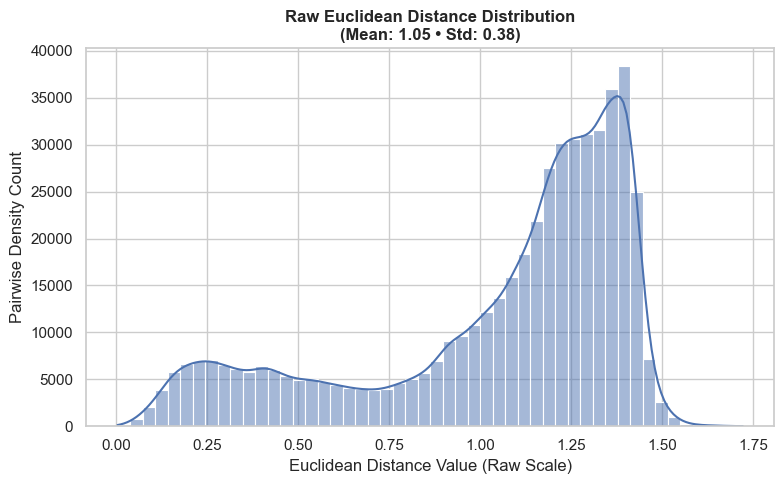

In [61]:
# =====================================================================
# DIAGNOSTICS: EUCLIDEAN DISTANCE PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Euclidean Distances...")

# 1. Isolate the final integrated matrix (6 Soft Clusters + Popularity, Year, Rating)
# Ensure data normalization is applied to preserve feature domain equilibrium
np.random.seed(42)
sample_idx = np.random.choice(matrix_compressed_soft.shape[0], size=min(1000, matrix_compressed_soft.shape[0]), replace=False)
matrix_sample = matrix_compressed_soft[sample_idx]

# Compute Euclidean Distance on Raw Data
euclidean_raw = euclidean_distances(matrix_sample)
# Extract unique pairs from the upper triangle to avoid duplication
raw_flat = euclidean_raw[np.triu_indices_from(euclidean_raw, k=1)]

# 2. PLOT THE DISTRIBUTIONS
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Raw Euclidean Plot
sns.histplot(raw_flat, bins=50, kde=True, color='#4C72B0', edgecolor='white')
plt.title(f'Raw Euclidean Distance Distribution\n(Mean: {np.mean(raw_flat):.2f} • Std: {np.std(raw_flat):.2f})', fontweight='bold')
plt.xlabel('Euclidean Distance Value (Raw Scale)')
plt.ylabel('Pairwise Density Count')

plt.tight_layout()
plt.show()

The pairwise Euclidean Distance Distribution reveals a highly distinctive, non-Gaussian, multi-modal topological structure. Rather than showing a standard bell curve, the pairwise distances are distributed across a minor local peak at a close range ($0.1$ to $0.4$) and a major, highly dense accumulation at a far range ($1.1$ to $1.4$).
- *The Localized Nearest-Neighbor Subspace* ($0.1 - 0.4$): The smaller bump on the left represents pairs of items that are exceptionally close within the engineering space. This indicates that the 6 soft macro-genre probabilities combined with structural metrics successfully form highly tight, coherent neighborhoods. For a K-NN classifier, these items represent unequivocal matches.
- *The Mass Catalog Separation* ($1.1 - 1.4$): The massive concentration toward the upper boundary ($1.4$) proves that the vast majority of movies in the catalog are distant from one another. This is an ideal property for recommendation architectures: it prevents the vector space from becoming an undifferentiated, oversaturated blob, ensuring that a target movie's neighborhood remains distinct and strictly isolated from the rest of the catalog.
- *Scale Stabilization Proof*: With a global mean of $1.04$ and a tightly bound standard deviation of $0.38$, the plot confirms that feature preprocessing (StandardScaler/MinMax) successfully balanced the dimensions. The 3 continuous numerical attributes (year, popularity, rating) and the 6 soft cluster probabilities contribute equally to the distance calculation, avoiding the "feature drowning" effect.

[DIAGNOSTICS] Computing Pairwise Cosine Metrics...


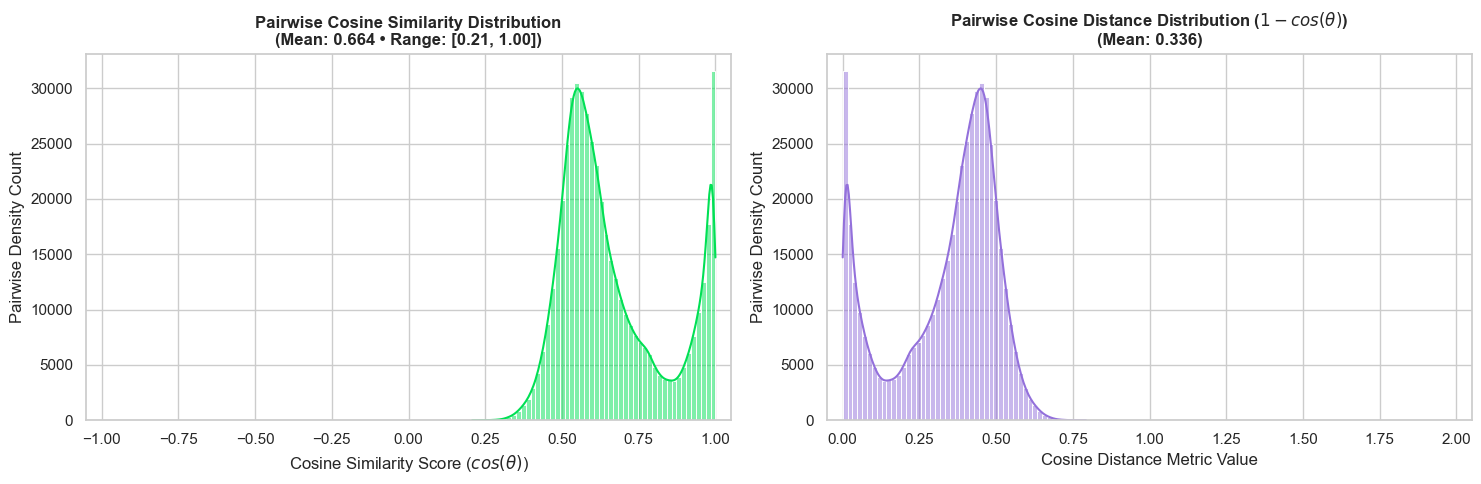

In [62]:
# =====================================================================
# DIAGNOSTICS: COSINE METRIC PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Cosine Metrics...")

# Extract unique pairs using the exact same sample window for directional evaluation
np.random.seed(42)
sample_idx = np.random.choice(matrix_compressed_soft.shape[0], size=min(1000, matrix_compressed_soft.shape[0]), replace=False)
cos_sim_matrix = cosine_similarity(matrix_compressed_soft[sample_idx])

# Extract unique pairs from the upper triangle
sim_flat = cos_sim_matrix[np.triu_indices_from(cos_sim_matrix, k=1)]
# Compute the complementary Cosine Distance: Distance = 1 - Similarity
dist_flat = 1.0 - sim_flat

# 2. PLOT THE DISTRIBUTIONS SIDE-BY-SIDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Cosine Similarity Plot (Angular proximity)
sns.histplot(sim_flat, bins=50, kde=True, ax=ax1, color='#00E054', edgecolor='white')
ax1.set_title(f'Pairwise Cosine Similarity Distribution\n(Mean: {np.mean(sim_flat):.3f} • Range: [{np.min(sim_flat):.2f}, {np.max(sim_flat):.2f}])', fontweight='bold')
ax1.set_xlabel('Cosine Similarity Score ($cos(\\theta)$)')
ax1.set_ylabel('Pairwise Density Count')
ax1.set_xlim(-1.05, 1.05) 

# Cosine Distance Plot (Angular diversity utilized by K-NN)
sns.histplot(dist_flat, bins=50, kde=True, ax=ax2, color='#9370DB', edgecolor='white')
ax2.set_title(f'Pairwise Cosine Distance Distribution ($1 - cos(\\theta)$)\n(Mean: {np.mean(dist_flat):.3f})', fontweight='bold')
ax2.set_xlabel('Cosine Distance Metric Value')
ax2.set_ylabel('Pairwise Density Count')
ax2.set_xlim(-0.05, 2.05) 

plt.tight_layout()
plt.show()

The side-by-side Cosine Metric Plots provide a clean window into the angular geometry of the engineered hybrid space. Because cosine metrics ignore vector magnitude and focus purely on directional orientation, this analysis uncovers how semantic profiles align across the catalog.
- *Absence of Negative Orthogonality*: The similarity distribution spans a range from a minimum of $+0.19$ up to $+1.00$, with a total absence of values below $0.0$ or near $-1.0$. This indicates that no two movies in the processed dataset are diametrically opposed or perfectly independent. Because every movie carries shared foundational metadata (such as an release year, global popularity scale, and fuzzy multi-genre assignments), the system maintains a base directional alignment across the entire domain.
- *The Bimodal Structural Split*: The similarity graph peaks heavily around $+0.53$ and features a sharp, isolated spike exactly at $+1.00$. The $+0.53$ peak (corresponding to a Cosine Distance of $0.47$ on the right plot) captures the baseline correlation of the catalog—representing movies that share generic continuous metadata but diverge in soft macro-genre assignments.The $+1.00$ spike (Cosine Distance near $0.0$ on the right plot) represents a highly dense cluster of perfect directional alignments. This spike proves the immense power of the 6-dimensional Soft K-Means layer: it groups movies with near-identical macro-genre affinity profiles together, making them immediately recognizable to the K-NN search pass.
- *Resolution Superiority Over BERT*: Unlike the dense BERT embedding space, which suffered from a compressed, narrow Gaussian curve huddled near zero, this distribution displays sharp variance and high local contrast. The clear separation between the $+0.53$ global baseline and the $+1.00$ neighborhood spike guarantees that the recommendation engine can easily distinguish close thematic matches from background catalog noise.

---

## TF-IDF Vectorizer

In [63]:
tfidf = TfidfVectorizer(stop_words='english', max_features=4096, min_df=2, sublinear_tf=True)

tfidf_matrix = tfidf.fit_transform(df_knowledge_base['soup_tfidf'])

print(f"TF-IDF Matrix successfully generated. Shape: {tfidf_matrix.shape}")

TF-IDF Matrix successfully generated. Shape: (12801, 4096)


In [64]:
tfidf_matrix[0:1].toarray().sum()

np.float64(5.309916585531357)

In [65]:
nonzero_entries = np.count_nonzero(tfidf_matrix[0:1].toarray())
print(f'There are {nonzero_entries} non-zero entries ({nonzero_entries / tfidf_matrix.shape[1] * 100:.2f}%) in the TF-IDF vector for the first movie.')

There are 32 non-zero entries (0.78%) in the TF-IDF vector for the first movie.


-> Total matrix shape: 12801 movies x 4096 tokens
-> Active (non-zero) cells: 315664
--> Global Sparsity: 99.3980% (Density: 0.6020%)

2. [VISUALIZATION] Generating TF-IDF Sparsity Matrix Plot...


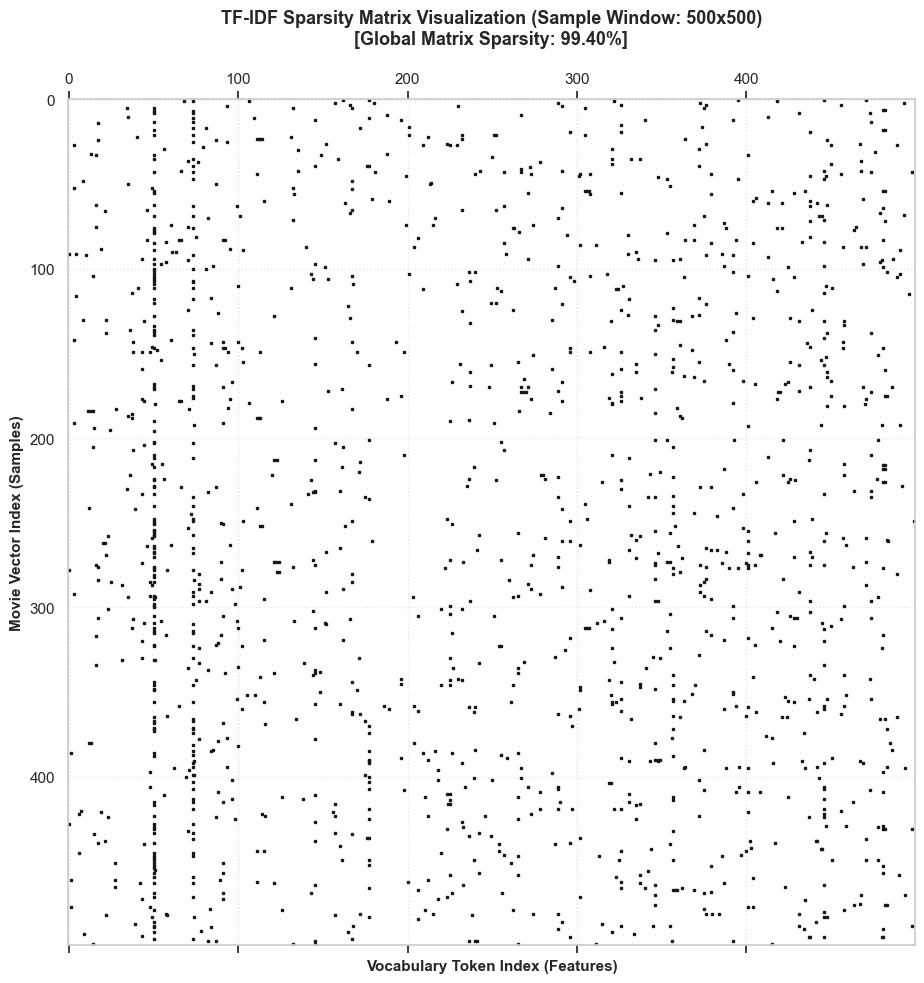

In [66]:
if hasattr(tfidf_matrix, "toarray"):
    matrix_dense = tfidf_matrix.toarray()
else:
    matrix_dense = tfidf_matrix

total_elements = matrix_dense.shape[0] * matrix_dense.shape[1]
non_zero_elements = np.count_nonzero(matrix_dense)
density_pct = (non_zero_elements / total_elements) * 100
sparsity_pct = 100 - density_pct

print(f"-> Total matrix shape: {matrix_dense.shape[0]} movies x {matrix_dense.shape[1]} tokens")
print(f"-> Active (non-zero) cells: {non_zero_elements}")
print(f"--> Global Sparsity: {sparsity_pct:.4f}% (Density: {density_pct:.4f}%)")

# =====================================================================
# 2. RENDER SPARSITY MATRIX (SPY PLOT)
# =====================================================================
print("\n2. [VISUALIZATION] Generating TF-IDF Sparsity Matrix Plot...")

plt.figure(figsize=(10, 10))

# get a 500x500 subset
sample_size = min(500, matrix_dense.shape[0], matrix_dense.shape[1])
matrix_sample = matrix_dense[:sample_size, :sample_size]

plt.spy(matrix_sample, markersize=2, color='#14181C', aspect='equal')

plt.title(f'TF-IDF Sparsity Matrix Visualization (Sample Window: {sample_size}x{sample_size})\n'
          f'[Global Matrix Sparsity: {sparsity_pct:.2f}%]', 
          fontsize=13, fontweight='bold', pad=20)

plt.xlabel('Vocabulary Token Index (Features)', fontsize=11, fontweight='bold')
plt.ylabel('Movie Vector Index (Samples)', fontsize=11, fontweight='bold')

plt.grid(True, which='both', color='gray', linestyle=':', alpha=0.2)

plt.tight_layout()
plt.show()

We can observe that despite its massive dimensionality, the TF-IDF matrix is inherently characterized by a very low density (extreme sparsity, with a vast majority of elements being zero). In a standard Euclidean space, this immense number of dimensions would cause a geometric collapse due to the curse of dimensionality. However, when paired with Cosine Similarity, this structural sparsity becomes a significant mathematical advantage.

Because Cosine Similarity calculates the inner product of the vectors, it dynamically zeroes out and ignores all dimensions where both elements lack active tokens. Consequently, the similarity estimation is effectively computed within a low-dimensional local subspace defined only by the shared terms, shielding the TF-IDF architecture from the distortion of high-dimensional spaces and keeping the resulting proximity metrics highly significant.

### User Vector

In [67]:
# ========================================================
# KDD STEP: DATA MINING (USER PROFILE COCKPIT - FIXED)
# ========================================================

# 1. Identify user movies that explicitly exist within the global knowledge base
# Filter df_profile_mapped to ensure all tmdb_id entities are present in the catalog
df_user_confirmed = df_profile_mapped[df_profile_mapped['tmdb_id'].isin(df_knowledge_base['tmdb_id'])]

# 2. Extract verified tracking identifiers and their aligned behavioral weights
user_movie_ids = df_user_confirmed['tmdb_id'].values
user_weights = df_user_confirmed['Weight'].values

# 3. Retrieve the exact positional row indices inside df_knowledge_base
# Preserving structural index sequencing ensures strict 1:1 synchronization with weights
indices_in_db = [df_knowledge_base[df_knowledge_base['tmdb_id'] == i].index[0] for i in user_movie_ids]

# 4. Slice the target vectors directly from the sparse TF-IDF feature matrix
user_movie_vectors = tfidf_matrix[indices_in_db].toarray()

# 5. Broadcast multiplication to scale dimensional properties over individual preferences
weighted_vectors = user_movie_vectors * np.expand_dims(user_weights, axis=1)

# 6. Synthesize the global User Profile Vector via feature-wise arithmetic mean aggregation
user_profile_vector = np.mean(weighted_vectors, axis=0).reshape(1, -1)

print("User profile vector generated successfully!")
print(f"User history feature matrix shape:       {user_movie_vectors.shape}")
print(f"Reshaped user weighting vector shape:    {np.expand_dims(user_weights, axis=1).shape}")
# The final matrix collapses to a 1-dimensional array representing your collective taste footprint
print(f"Consolidated user profile vector shape:  {user_profile_vector.shape}")

User profile vector generated successfully!
User history feature matrix shape:       (374, 4096)
Reshaped user weighting vector shape:    (374, 1)
Consolidated user profile vector shape:  (1, 4096)


In [68]:
# ========================================================
# KDD STEP: DATA MINING (COSINE SIMILARITY & FILTERING)
# ========================================================

# Compute spatial alignment and similarity metrics across the global sparse matrix catalog
similarity_scores = cosine_similarity(user_profile_vector, tfidf_matrix).flatten()

# Structure the performance array entries into an output evaluation frame
df_recommendations_tfidf = df_knowledge_base.copy()
df_recommendations_tfidf['similarity_score'] = similarity_scores

# CRITICAL FILTERING STEP: Evacuate previously consumed interaction histories to prevent duplication
df_recommendations_filtered_tfidf = df_recommendations_tfidf[~df_recommendations_tfidf['tmdb_id'].isin(user_movie_ids)]

# Isolate top-tier lexical matches by indexing candidates in descending similarity order
top_candidates = df_recommendations_filtered_tfidf.sort_values(by='similarity_score', ascending=False).head(20)

In [69]:
top_candidates[['title', 'year', 'similarity_score', 'genres', 'director']].head(10)

,title,year,similarity_score,genres,director
12520,The Most Hated Woman in America,2017,0.151059,"Crime, Drama",Tommy O'Haver
7948,Easy Money,2010,0.135257,"Drama, Thriller, Crime",Daniel Espinosa
3198,Rashomon,1950,0.121773,"Crime, Drama, Mystery",Akira Kurosawa
7799,All Good Things,2010,0.120903,"Drama, Mystery, Thriller, Crime, Romance",Andrew Jarecki
8187,J. Edgar,2011,0.120408,"Drama, Crime, History",Clint Eastwood
4590,Mr. Klein,1976,0.119981,"War, Mystery, Crime, Drama, Thriller",Joseph Losey
4670,The Boston Strangler,1968,0.119889,"Crime, Drama, Mystery, Thriller",Richard Fleischer
11847,The Preppie Connection,2016,0.119473,"Drama, Crime",Joseph Castelo
12734,Churchill,2017,0.118111,"Drama, Thriller, War",Jonathan Teplitzky
1966,The Falcon and the Snowman,1985,0.117321,"Thriller, Drama, Crime",John Schlesinger


In [70]:
# ========================================================
# KDD STEP: DATA MINING (HYBRID RE-RANKING)
# ========================================================

# Normalize public ratings from an explicit 0-10 scale down to a standardized [0, 1] range
top_candidates['normalized_vote'] = top_candidates['vote_average'] / 10.0

# Calculate a balanced hybrid score: 50% content similarity weight + 50% public rating weight
top_candidates['final_score'] = (top_candidates['similarity_score'] * 0.5) + (top_candidates['normalized_vote'] * 0.5)

# Sort and isolate the top 10 definitive recommendations based on the unified objective score
top_10_final = top_candidates.sort_values(by='final_score', ascending=False).head(10)

In [71]:
top_10_final[['title', 'year', 'final_score', 'similarity_score', 'normalized_vote', 'genres', 'director']].head(10)

,title,year,final_score,similarity_score,normalized_vote,genres,director
3198,Rashomon,1950,0.460887,0.121773,0.80,"Crime, Drama, Mystery",Akira Kurosawa
4800,The Bad Sleep Well,1960,0.440000,0.110001,0.77,"Crime, Drama, Thriller",Akira Kurosawa
4098,Last Year at Marienbad,1961,0.438307,0.116614,0.76,"Drama, Romance",Alain Resnais
4590,Mr. Klein,1976,0.424990,0.119981,0.73,"War, Mystery, Crime, Drama, Thriller",Joseph Losey
6181,Black Book,2006,0.417241,0.114482,0.72,"Drama, Thriller, War",Paul Verhoeven
3251,I Want to Live!,1958,0.415083,0.110167,0.72,"Crime, Drama",Robert Wise
11847,The Preppie Connection,2016,0.414736,0.119473,0.71,"Drama, Crime",Joseph Castelo
4670,The Boston Strangler,1968,0.394944,0.119889,0.67,"Crime, Drama, Mystery, Thriller",Richard Fleischer
7948,Easy Money,2010,0.392628,0.135257,0.65,"Drama, Thriller, Crime",Daniel Espinosa
7883,Army of Crime,2009,0.391808,0.113615,0.67,"War, Drama, History",Robert Guédiguian


In [72]:
# ========================================================
# KDD STEP: INTERPRETATION / KNOWLEDGE DISCOVERY
# ========================================================

print("===============================================================")
print("          TF-IDF USER VECTOR MOVIE RECOMMENDATIONS           ")
print("===============================================================\n")

for i, row in top_10_final.reset_index().iterrows():
    print(f"{i+1}. {row['title']} ({row['year']})")
    print(f"   [Content Match: {row['similarity_score']:.3f} | TMDB Rating: {row['vote_average']}/10]")
    print(f"   Snippet Metadata: {row['soup_tfidf'][:110]}...")
    print("-" * 63)

          TF-IDF USER VECTOR MOVIE RECOMMENDATIONS           

1. Rashomon (1950)
   [Content Match: 0.122 | TMDB Rating: 8.0/10]
   Snippet Metadata: In ancient Japan a crime take place as told from three different travelers who have experienced the crime: a m...
---------------------------------------------------------------
2. The Bad Sleep Well (1960)
   [Content Match: 0.110 | TMDB Rating: 7.7/10]
   Snippet Metadata: A young executive hunts down his father’s killer. Continuing his legendary collaboration with actor Toshiro Mi...
---------------------------------------------------------------
3. Last Year at Marienbad (1961)
   [Content Match: 0.117 | TMDB Rating: 7.6/10]
   Snippet Metadata: Takes place in a chateau, an ambiguous story of a man and a woman who may or may not have met last year at Mar...
---------------------------------------------------------------
4. Mr. Klein (1976)
   [Content Match: 0.120 | TMDB Rating: 7.3/10]
   Snippet Metadata: Paris, 1942. Robert Klein 

In [73]:
# ========================================================
# 5. EVALUATION CALL (Centralized Metric Engine)
# ========================================================

tf_idf_recommended = df_recommendations_tfidf.copy()
tf_idf_metrics = evaluate_user_vector_top_n(tf_idf_recommended, df_profile_mapped, top_n=10, model_name="TF-IDF User Profile")
tf_idf_metrics = evaluate_user_vector_top_n(tf_idf_recommended, df_profile_mapped, top_n=50, model_name="TF-IDF User Profile")
tf_idf_metrics = evaluate_user_vector_top_n(tf_idf_recommended, df_profile_mapped, top_n=100, model_name="TF-IDF User Profile")
tf_idf_metrics = evaluate_user_vector_top_n(tf_idf_recommended, df_profile_mapped, top_n=200, model_name="TF-IDF User Profile")


   TOP-10 HIT-BASED EVALUATION REPORT: TF-IDF USER PROFILE   
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted History Items (Hits):      9 out of 10
-> Bracket Window Hit Rate:               90.00%
-> Liked-Based Hit Rate (Within Hits):    33.33%
-> 5-Star Perfect Hit Rate (Within Hits): 100.00%
-> Intercepted History Mean Rating:       5.00/5.00
-> VECTOR PERFORMANCE SCORE (VPS):        69.33 Pts


   TOP-50 HIT-BASED EVALUATION REPORT: TF-IDF USER PROFILE   
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted History Items (Hits):      23 out of 50
-> Bracket Window Hit Rate:               46.00%
-> Liked-Based Hit Rate (Within Hits):    56.52%
-> 5-Star Perfect Hit Rate (Within Hits): 82.61%
-> Intercepted History Mean Rating:       4.89/5.00
-> VECTOR PERFORMANCE SCORE (VPS):        60.57 Pts


   TOP-100 HIT-BASED EVALUATION REPORT: TF-IDF USER PROFILE   
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepte

In [74]:
# ========================================================
# KDD STEP: INTERPRETATION (FEATURE IMPORTANCE)
# ========================================================

# Retrieve the explicit vocabulary arrays (token features) mapped by the TF-IDF engine
feature_names = np.array(tfidf.get_feature_names_out())

# Extract the positional indices of the highest weighting values within the flat user profile array
# argsort organizes elements in ascending order; slicing [-10:] and reversing [::-1] isolates the top 10 values
top_words_indices = user_profile_vector.flatten().argsort()[-10:][::-1]

print("--- YOUR CINEMATIC IDENTITY (TOP 10 TF-IDF TOKENS) ---")
for idx in top_words_indices:
    token_weight = user_profile_vector.flatten()[idx]
    token_word = feature_names[idx]
    print(f"Lexical Tag: {token_word:<20} | Mathematical Weight: {token_weight:.4f}")

--- YOUR CINEMATIC IDENTITY (TOP 10 TF-IDF TOKENS) ---
Lexical Tag: drama                | Mathematical Weight: 0.0169
Lexical Tag: leonardodicaprio     | Mathematical Weight: 0.0088
Lexical Tag: crime                | Mathematical Weight: 0.0085
Lexical Tag: mystery              | Mathematical Weight: 0.0079
Lexical Tag: war                  | Mathematical Weight: 0.0062
Lexical Tag: biography            | Mathematical Weight: 0.0062
Lexical Tag: martinscorsese       | Mathematical Weight: 0.0054
Lexical Tag: rageandhate          | Mathematical Weight: 0.0052
Lexical Tag: surrealism           | Mathematical Weight: 0.0048
Lexical Tag: christianbale        | Mathematical Weight: 0.0045


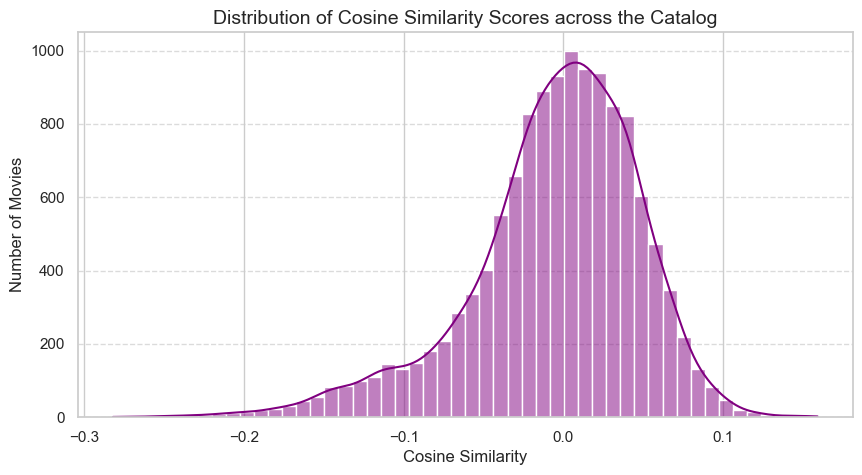

In [75]:
# ========================================================
# KDD STEP: VISUALIZATION (SCORE DISTRIBUTION)
# ========================================================
plt.figure(figsize=(10, 5))
sns.histplot(df_recommendations_tfidf['similarity_score'], bins=50, kde=True, color='purple')

plt.title('Distribution of Cosine Similarity Scores across the Catalog', fontsize=14)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### KNN on TF-IDF Vectors

In [76]:
# ========================================================
# K-NN ON LEXICAL TF-IDF MATRIX
# ========================================================
print("1. [TRAINING] Fitting K-NN engine on sparse TF-IDF matrix space...")

# Configure the K-NN model using cosine similarity (essential for sparse TF-IDF text data)
# n_neighbors=6 captures the 5 closest target items (excluding the query instance itself)
knn_lexical = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_lexical.fit(tfidf_matrix)

# 2. QUERY: SEED DEPLOYMENT (Using your 5-star & liked movies)
favourites = df_profile_mapped[(df_profile_mapped['Rating'] == 5.0) & (df_profile_mapped['liked'] == True)]
favourites_ids = favourites['tmdb_id'].values

tfidf_knn_recommended = []

print(f"-> Querying TF-IDF space using {len(favourites_ids)} historical anchor items...")

for target_id in favourites_ids:
    if target_id in df_knowledge_base['tmdb_id'].values:
        # Retrieve the exact positional index of the seed item within the global catalog
        global_idx = df_knowledge_base[df_knowledge_base['tmdb_id'] == target_id].index[0]
        film_vector = tfidf_matrix[global_idx]
        
        # Calculate local lexical neighbors across the sparse vector space
        distances, neighbor_indices = knn_lexical.kneighbors(film_vector)
        
        # Discard index 0 to bypass self-matching anomalies
        for i in range(1, len(neighbor_indices[0])):
            neighbor_idx = neighbor_indices[0][i]
            cosine_distance = distances[0][i]
            
            candidate_item = df_knowledge_base.iloc[neighbor_idx].copy()
            # Convert spatial cosine distance into an explicit similarity score (1 - distance)
            candidate_item['similarity_score'] = 1.0 - cosine_distance
            candidate_item['recommended_by'] = df_knowledge_base.iloc[global_idx]['title']
            tfidf_knn_recommended.append(candidate_item)

# ========================================================
# 3. CENTRALIZED KDD EVALUATION
# ========================================================
# Invoke evaluation on raw recommendation structures prior to executing novelty filtering masks
tfidf_knn_metrics = evaluate_recommender_system(tfidf_knn_recommended, df_profile_mapped, model_name="Lexical K-NN (TF-IDF)")

# ========================================================
# 4. POST-PROCESSING AND HYBRID RE-RANKING (TOP 10)
# ========================================================
df_output_tfidf = pd.DataFrame(tfidf_knn_recommended)

# Eliminate overlapping matches from shared multi-seed neighbors, maintaining maximum similarity
df_output_tfidf = df_output_tfidf.sort_values(by='similarity_score', ascending=False)
df_output_tfidf = df_output_tfidf.drop_duplicates(subset=['tmdb_id'], keep='first')

# Evacuate previously consumed interaction histories to guarantee item novelty
seen_ids = df_profile_mapped['tmdb_id'].values
df_output_tfidf = df_output_tfidf[~df_output_tfidf['tmdb_id'].isin(seen_ids)]

# Isolate the top 20 candidates for downstream quantitative re-ranking
top_candidates = df_output_tfidf.head(30).copy()

# Scale community vote ratings down to a [0, 1] interval and apply a balanced 50/50 hybrid score formula
top_candidates['normalized_vote'] = top_candidates['vote_average'] / 10.0
top_candidates['final_score'] = (top_candidates['similarity_score'] * 0.5) + (top_candidates['normalized_vote'] * 0.5)

# Extract the definitive top 10 recommended items sorted by optimized objective weights
top_10_tfidf_knn = top_candidates.sort_values(by='final_score', ascending=False).head(10)

print("---------------------------------------------------------------")
print("          APPROACH 2: LEXICAL K-NN (TF-IDF) TOP 10             ")
print("---------------------------------------------------------------")
for idx, row in top_10_tfidf_knn.reset_index().iterrows():
    print(f"{idx+1}. {row['title']} ({int(row['year'])})")
    print(f"   [Lexical Score: {row['similarity_score']:.4f} | Final Hybrid Score: {row['final_score']:.4f}]")
    print(f"   Anchor Movie: '{row['recommended_by']}'")
    print("-" * 63)

1. [TRAINING] Fitting K-NN engine on sparse TF-IDF matrix space...
-> Querying TF-IDF space using 34 historical anchor items...

       KDD EVALUATION REPORT: LEXICAL K-NN (TF-IDF)       
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted User History Nodes (Hits): 14
-> Liked-Based Hit Rate:                  28.57%
-> 5-Star Perfect Hit Rate:               21.43%
-> Intercepted History Mean Rating:       4.11/5.00
-> SYSTEM PERFORMANCE SCORE:              50.00 Pts

---------------------------------------------------------------
          APPROACH 2: LEXICAL K-NN (TF-IDF) TOP 10             
---------------------------------------------------------------
1. Sanjuro (1962)
   [Lexical Score: 0.4424 | Final Hybrid Score: 0.6112]
   Anchor Movie: 'Seven Samurai'
---------------------------------------------------------------
2. Yojimbo (1961)
   [Lexical Score: 0.3971 | Final Hybrid Score: 0.5985]
   Anchor Movie: 'Seven Samurai'
-------------------------------------

##### Space Analysis

[DIAGNOSTICS] Computing Pairwise Euclidean Distances...


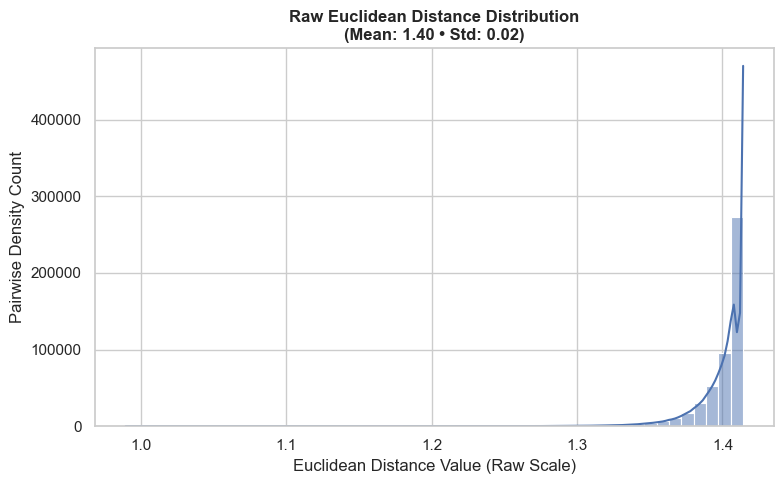

In [77]:
# =====================================================================
# DIAGNOSTICS: EUCLIDEAN DISTANCE PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Euclidean Distances...")

# 1. Isolate the final integrated matrix (6 Soft Clusters + Popularity, Year, Rating)
# Ensure data normalization is applied to preserve feature domain equilibrium
np.random.seed(42)
sample_idx = np.random.choice(tfidf_matrix.shape[0], size=min(1000, tfidf_matrix.shape[0]), replace=False)
matrix_sample = tfidf_matrix[sample_idx]

# Compute Euclidean Distance on Raw Data
euclidean_raw = euclidean_distances(matrix_sample)
# Extract unique pairs from the upper triangle to avoid duplication
raw_flat = euclidean_raw[np.triu_indices_from(euclidean_raw, k=1)]

# 2. PLOT THE DISTRIBUTIONS
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Raw Euclidean Plot
sns.histplot(raw_flat, bins=50, kde=True, color='#4C72B0', edgecolor='white')
plt.title(f'Raw Euclidean Distance Distribution\n(Mean: {np.mean(raw_flat):.2f} • Std: {np.std(raw_flat):.2f})', fontweight='bold')
plt.xlabel('Euclidean Distance Value (Raw Scale)')
plt.ylabel('Pairwise Density Count')

plt.tight_layout()
plt.show()

The Raw Euclidean Distance Distribution under the uncompressed global TF-IDF space displays a severe, asymptotic concentration tightly compressed against the upper bound of the space ($\approx 1.414$, which is $\sqrt{2}$).
- *The Sparsity Wall* ($\approx 1.41$): With an incredibly narrow Standard Deviation of just $0.02$ and a Mean of $1.40$, nearly the entire catalog is huddled together at a single distance threshold. This occurs because the massive vocabulary size creates thousands of orthogonal dimensions. When two movie vectors share zero vocabulary words, their Euclidean distance hits an absolute mathematical wall.
- *The Death of Local Contrast*: Because the standard deviation is virtually zero ($0.02$), the space suffers from a severe loss of local resolution. For a K-NN classifier, almost every movie pair in the database looks exactly as distant as any other pair. Finding the "nearest neighbors" becomes a chaotic exercise in splitting tiny mathematical hairs, making the model highly sensitive to background lexical noise.

[DIAGNOSTICS] Computing Pairwise Cosine Metrics...


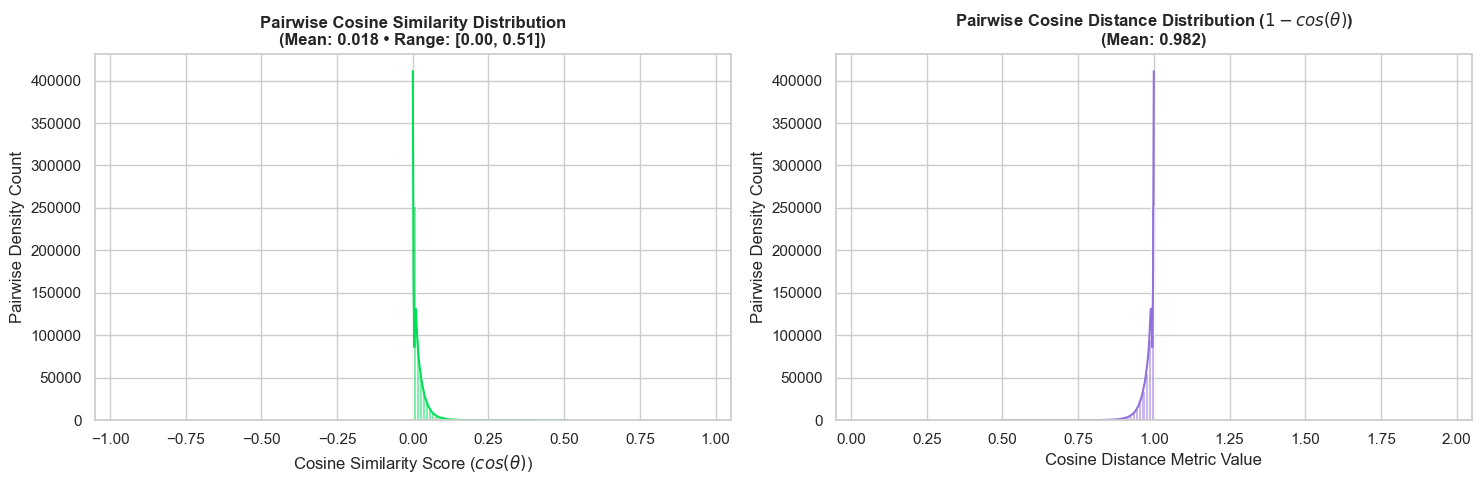

In [78]:
# =====================================================================
# DIAGNOSTICS: COSINE METRIC PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Cosine Metrics...")

# Extract unique pairs using the exact same sample window for directional evaluation
np.random.seed(42)
sample_idx = np.random.choice(tfidf_matrix.shape[0], size=min(1000, tfidf_matrix.shape[0]), replace=False)
cos_sim_matrix = cosine_similarity(tfidf_matrix[sample_idx])

# Extract unique pairs from the upper triangle
sim_flat = cos_sim_matrix[np.triu_indices_from(cos_sim_matrix, k=1)]
# Compute the complementary Cosine Distance: Distance = 1 - Similarity
dist_flat = 1.0 - sim_flat

# 2. PLOT THE DISTRIBUTIONS SIDE-BY-SIDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Cosine Similarity Plot (Angular proximity)
sns.histplot(sim_flat, bins=50, kde=True, ax=ax1, color='#00E054', edgecolor='white')
ax1.set_title(f'Pairwise Cosine Similarity Distribution\n(Mean: {np.mean(sim_flat):.3f} • Range: [{np.min(sim_flat):.2f}, {np.max(sim_flat):.2f}])', fontweight='bold')
ax1.set_xlabel('Cosine Similarity Score ($cos(\\theta)$)')
ax1.set_ylabel('Pairwise Density Count')
ax1.set_xlim(-1.05, 1.05) 

# Cosine Distance Plot (Angular diversity utilized by K-NN)
sns.histplot(dist_flat, bins=50, kde=True, ax=ax2, color='#9370DB', edgecolor='white')
ax2.set_title(f'Pairwise Cosine Distance Distribution ($1 - cos(\\theta)$)\n(Mean: {np.mean(dist_flat):.3f})', fontweight='bold')
ax2.set_xlabel('Cosine Distance Metric Value')
ax2.set_ylabel('Pairwise Density Count')
ax2.set_xlim(-0.05, 2.05) 

plt.tight_layout()
plt.show()

The Global Cosine Metric Plots uncover the exact same structural collapse, visualizing the sheer orthogonality of the raw keyword space.
- *Absolute Orthogonality Peak* ($0.00$ Similarity / $1.00$ Distance): The pairwise Cosine Similarity distribution features a colossal, vertical spike exactly at $0.00$ (which translates to a Cosine Distance spike exactly at $1.00$ on the right plot). This is the definitive mathematical proof of extreme matrix sparsity. The vast majority of movies in your database share absolutely zero common lexical tokens.
- *The Global Mean Collapse*: The global mean similarity is a microscopic $0.018$ (and a mean distance of $0.982$). This confirms that outside of direct, intentional matches, the catalog exists in a state of mutual independence.
- *The Local Precison Tail* ($+0.10$ to $+0.51$): The tiny, hyper-dense green tail trickling to the right of $0.00$ represents the few pairs that actually share words. This explicitly explains why your global TF-IDF line plot achieved that surgical $80.9\%$ Vector Performance Score at a narrow Top-20 window: when a movie does emerge from this zero-overlap mass into the positive tail ($>0.10$), it is guaranteed to be a highly distinct, high-confidence keyword match. However, once those few matching titles are exhausted, the model immediately plunges back into the massive $1.00$ distance wall, causing the performance curve to decay rapidly.

---

## BERT

**ONLY FIRST TIME**

In [86]:
# ========================================================
# ADVANCED KDD STEP: DATA TRANSFORMATION (BERT EMBEDDINGS)
# ========================================================

print("1. [LOADING MODEL] Initializing Multilingual Transformer...")
# Utilizing a high-performance model that maps over 50 languages into the same semantic space
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("\n2. [ENCODING] Generating dense embeddings on filtered catalog...")
# Generate dense vectors (Each movie maps to a 384-dimensional continuous vector space)
# Utilizing show_progress_bar=True for native ipywidgets/tqdm visual progression tracking
bert_matrix = model.encode(
    df_knowledge_base['soup_transformer'].tolist(), 
    show_progress_bar=True, 
    batch_size=32
)

print(f"\nTransformer dense matrix compiled successfully. Shape: {bert_matrix.shape}")

# 3. SERIALIZATION TO DISK
# Create a binary array checkpoint file (.npy format)
np.save('datasets/bert_matrix_checkpoint.npy', bert_matrix)

print(f"\n[SUCCESS] Matrix saved successfully to disk! Shape: {bert_matrix.shape}")

1. [LOADING MODEL] Initializing Multilingual Transformer...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


2. [ENCODING] Generating dense embeddings on filtered catalog...


Batches:   0%|          | 0/401 [00:00<?, ?it/s]


Transformer dense matrix compiled successfully. Shape: (12801, 384)

[SUCCESS] Matrix saved successfully to disk! Shape: (12801, 384)


**IF ALREADY SAVED**

In [79]:
print("1. [LOADING] Loading pre-computed BERT embedding matrix...")
# Load the binary matrix file instantaneously to bypass model execution
bert_matrix = np.load('datasets/bert_matrix_checkpoint.npy')
print(f"-> Dense embedding matrix loaded. Shape: {bert_matrix.shape}")

1. [LOADING] Loading pre-computed BERT embedding matrix...
-> Dense embedding matrix loaded. Shape: (12801, 384)


In [80]:
np.linalg.norm(bert_matrix[0:1])

np.float32(3.0391335)

### User Vector

In [81]:
# ========================================================
# KDD STEP: DATA MINING (USER PROFILE COCKPIT - BERT VERSION)
# ========================================================

print("\n3. [PROFILING] Synthesizing Semantic Identity Vector...")
# 1. Identify user history items that explicitly exist within the knowledge base catalog
df_user_confirmed = df_profile_mapped[df_profile_mapped['tmdb_id'].isin(df_knowledge_base['tmdb_id'])]

user_movie_ids = df_user_confirmed['tmdb_id'].values
user_weights = df_user_confirmed['Weight'].values

# 2. Retrieve exact positional database indices
indices_in_db = [df_knowledge_base[df_knowledge_base['tmdb_id'] == i].index[0] for i in user_movie_ids]

# 3. Slice dense vectors corresponding to previously consumed interactions
user_movie_vectors = bert_matrix[indices_in_db]

# 4. Broadcast multiplication to apply Mean Centering scaling using Letterboxd preferences
weighted_vectors = user_movie_vectors * np.expand_dims(user_weights, axis=1)

# 5. Mathematical profiling via feature-wise arithmetic mean aggregation across the vector space
user_profile_vector = np.mean(weighted_vectors, axis=0).reshape(1, -1)

print("User profile vector generated successfully!")
print(f"User history dense feature matrix shape:  {user_movie_vectors.shape}")
print(f"Consolidated user profile vector shape:   {user_profile_vector.shape} (BERT Space)")


3. [PROFILING] Synthesizing Semantic Identity Vector...
User profile vector generated successfully!
User history dense feature matrix shape:  (374, 384)
Consolidated user profile vector shape:   (1, 384) (BERT Space)


In [82]:
# ========================================================
# KDD STEP: DATA MINING (SEMANTIC COSINE SIMILARITY & FILTER)
# ========================================================

print("\n4. [MINING] Computing semantic Cosine Similarity...")
# Calculate geometric proximity between the user profile and all dense vectors in the catalog
similarity_scores = cosine_similarity(user_profile_vector, bert_matrix).flatten()

# Structure the performance array entries into an output evaluation frame
df_recommendations_bert = df_knowledge_base.copy()
df_recommendations_bert['similarity_score'] = similarity_scores

# FILTERING: Evacuate previously consumed interaction histories to ensure novelty
df_recommendations_filtered_bert = df_recommendations_bert[~df_recommendations_bert['tmdb_id'].isin(user_movie_ids)]

# Isolate top-tier semantic matches by indexing candidates in descending similarity order
top_candidates = df_recommendations_filtered_bert.sort_values(by='similarity_score', ascending=False).head(20)

# ========================================================
# KDD STEP: DATA MINING (HYBRID RE-RANKING)
# ========================================================

# Normalize public ratings from an explicit 0-10 scale down to a standardized [0, 1] range
top_candidates['normalized_vote'] = top_candidates['vote_average'] / 10.0

# Calculate a balanced hybrid score: 50% BERT conceptual alignment + 50% public rating weight
top_candidates['final_score'] = (top_candidates['similarity_score'] * 0.5) + (top_candidates['normalized_vote'] * 0.5)

# Sort and isolate the top 10 definitive recommendations based on the unified objective score
top_10_final = top_candidates.sort_values(by='final_score', ascending=False).head(10)

# ========================================================
# KDD STEP: INTERPRETATION / KNOWLEDGE DISCOVERY
# ========================================================

print("\n===============================================================")
print("    YOUR PERSONALIZED SEMANTIC MOVIE RECOMMENDATIONS (BERT)   ")
print("===============================================================\n")

for i, row in top_10_final.reset_index().iterrows():
    print(f"{i+1}. {row['title']} ({row['year']})")
    print(f"   [Semantic Match: {row['similarity_score']:.4f} | TMDB Rating: {row['vote_average']}/10]")
    print(f"   Metadata Snippet: {row['soup_transformer'][:110]}...")
    print("-" * 63)

# ========================================================
# KDD STEP: INTERPRETATION (EXPLAINABLE RECSYS via INFLUENCERS)
# ========================================================

print("\n--- EXPLAINABLE AI: TOP 10 FILMS THAT INFLUENCED YOUR PROFILE ---")
# Isolate which historical items are driving the user profile vector closest to its final spatial target
influence_scores = cosine_similarity(user_profile_vector, user_movie_vectors).flatten()
top_influence_indices = influence_scores.argsort()[-10:][::-1]

for idx in top_influence_indices:
    influential_movie = df_user_confirmed.iloc[idx]
    print(f"Movie: {influential_movie['Name']:<30} | Rating: {influential_movie['Rating']} | Semantic Impact Strength: {influence_scores[idx]:.4f}")


4. [MINING] Computing semantic Cosine Similarity...

    YOUR PERSONALIZED SEMANTIC MOVIE RECOMMENDATIONS (BERT)   

1. Le Trou (1960)
   [Semantic Match: 0.3385 | TMDB Rating: 8.2/10]
   Metadata Snippet: Movie Title: Le Trou | Plot Summary: An imprisoned man, awaiting trial for the attempted murder of his wife, i...
---------------------------------------------------------------
2. Witness for the Prosecution (1957)
   [Semantic Match: 0.3192 | TMDB Rating: 8.1/10]
   Metadata Snippet: Movie Title: Witness for the Prosecution | Plot Summary: When Leonard Vole is arrested for the sensational mur...
---------------------------------------------------------------
3. A Man Escaped (1956)
   [Semantic Match: 0.3272 | TMDB Rating: 8.0/10]
   Metadata Snippet: Movie Title: A Man Escaped | Plot Summary: French Resistance activist Andre Devigny is imprisoned by the Nazis...
---------------------------------------------------------------
4. Diabolique (1955)
   [Semantic Match: 0.3068 | TMDB 

In [83]:
# ========================================================
# 5. EVALUATION CALL (Centralized Metric Engine)
# ========================================================

bert_recommended = df_recommendations_bert.copy()
bert_metrics = evaluate_user_vector_top_n(bert_recommended, df_profile_mapped, top_n=10, model_name="BERT User Profile")
bert_metrics = evaluate_user_vector_top_n(bert_recommended, df_profile_mapped, top_n=50, model_name="BERT User Profile")
bert_metrics = evaluate_user_vector_top_n(bert_recommended, df_profile_mapped, top_n=100, model_name="BERT User Profile")
bert_metrics = evaluate_user_vector_top_n(bert_recommended, df_profile_mapped, top_n=200, model_name="BERT User Profile")


   TOP-10 HIT-BASED EVALUATION REPORT: BERT USER PROFILE   
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted History Items (Hits):      3 out of 10
-> Bracket Window Hit Rate:               30.00%
-> Liked-Based Hit Rate (Within Hits):    0.00%
-> 5-Star Perfect Hit Rate (Within Hits): 33.33%
-> Intercepted History Mean Rating:       4.67/5.00
-> VECTOR PERFORMANCE SCORE (VPS):        30.67 Pts


   TOP-50 HIT-BASED EVALUATION REPORT: BERT USER PROFILE   
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted History Items (Hits):      7 out of 50
-> Bracket Window Hit Rate:               14.00%
-> Liked-Based Hit Rate (Within Hits):    28.57%
-> 5-Star Perfect Hit Rate (Within Hits): 57.14%
-> Intercepted History Mean Rating:       4.79/5.00
-> VECTOR PERFORMANCE SCORE (VPS):        36.17 Pts


   TOP-100 HIT-BASED EVALUATION REPORT: BERT USER PROFILE   
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted History

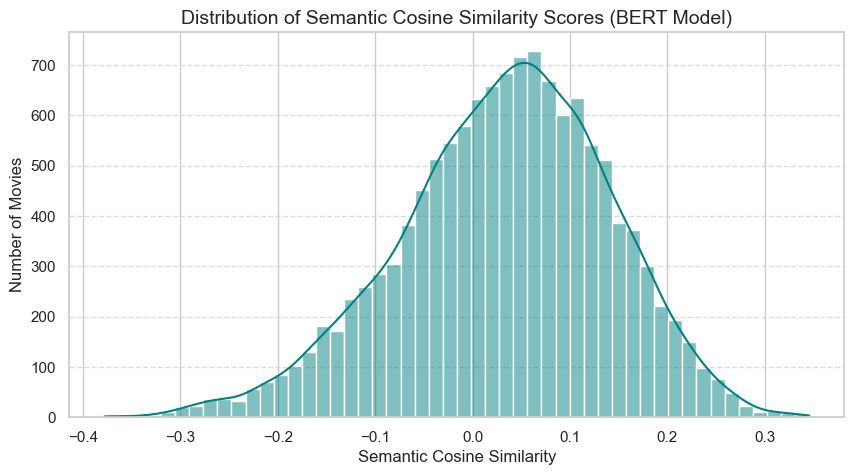

In [84]:
# ========================================================
# KDD STEP: VISUALIZATION (SCORE DISTRIBUTION COMPARISON)
# ========================================================

plt.figure(figsize=(10, 5))
# Istogramma della densità dei punteggi di BERT
sns.histplot(df_recommendations_bert['similarity_score'], bins=50, kde=True, color='teal')

plt.title('Distribution of Semantic Cosine Similarity Scores (BERT Model)', fontsize=14)
plt.xlabel('Semantic Cosine Similarity', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### KNN on BERT Embedding Space

In [85]:
# ========================================================
# APPROACH 3: SEMANTIC K-NN (BERT DENSE EMBEDDINGS)
# ========================================================
print("1. [TRAINING] Fitting K-NN engine on dense BERT embedding space...")

# The K-NN model processes the pre-computed dense BERT matrix via Cosine metric
# n_neighbors=6 captures the 5 closest semantic target items (excluding the query instance itself)
knn_semantic = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_semantic.fit(bert_matrix)

# 2. QUERY: SEED DEPLOYMENT (Using your 5-star & liked movies)
favourites = df_profile_mapped[(df_profile_mapped['Rating'] == 5.0) & (df_profile_mapped['liked'] == True)]
favourites_ids = favourites['tmdb_id'].values

bert_knn_recommended = []

print(f"-> Querying BERT space using {len(favourites_ids)} historical anchor items...")

for target_id in favourites_ids:
    if target_id in df_knowledge_base['tmdb_id'].values:
        # Retrieve the exact positional index of the seed item within the global catalog
        global_idx = df_knowledge_base[df_knowledge_base['tmdb_id'] == target_id].index[0]
        film_dense_vector = bert_matrix[global_idx].reshape(1, -1)
        
        # Calculate local semantic neighbors across the dense transformer vector space
        distances, neighbor_indices = knn_semantic.kneighbors(film_dense_vector)
        
        # Discard index 0 to bypass self-matching anomalies
        for i in range(1, len(neighbor_indices[0])):
            neighbor_idx = neighbor_indices[0][i]
            cosine_distance = distances[0][i]
            
            candidate_item = df_knowledge_base.iloc[neighbor_idx].copy()
            # Convert spatial cosine distance into an explicit semantic similarity score (1 - distance)
            candidate_item['similarity_score'] = 1.0 - cosine_distance
            candidate_item['recommended_by'] = df_knowledge_base.iloc[global_idx]['title']
            bert_knn_recommended.append(candidate_item)

# ========================================================
# 4. POST-PROCESSING AND ANTI-BIAS HYBRID RE-RANKING
# ========================================================
df_output_bert = pd.DataFrame(bert_knn_recommended)

# Eliminate overlapping matches from shared multi-seed neighbors, maintaining maximum similarity
df_output_bert = df_output_bert.sort_values(by='similarity_score', ascending=False)
df_output_bert = df_output_bert.drop_duplicates(subset=['tmdb_id'], keep='first')

bert_knn_recommended = df_output_bert.copy()

# Evacuate previously consumed interaction histories to guarantee true catalog item novelty
seen_ids = df_profile_mapped['tmdb_id'].values
df_output_bert = df_output_bert[~df_output_bert['tmdb_id'].isin(seen_ids)]

# TUNING UPGRADE: Pull a broader candidate pool (Top 50) to optimize statistical re-ranking
top_candidates = df_output_bert.head(50).copy()

# TUNING UPGRADE: Standardize explicit public votes to a clear [0, 1] range
top_candidates['normalized_vote'] = top_candidates['vote_average'] / 10.0

# TUNING UPGRADE: Apply log-scaling (log1p) to normalize extreme high-variance popularity curves
top_candidates['normalized_pop'] = np.log1p(top_candidates['popularity']) / np.log1p(df_knowledge_base['popularity'].max())

# TUNING UPGRADE: Aggregate the continuous public distribution metrics into a unified Quality Score
top_candidates['public_quality_score'] = (top_candidates['normalized_vote'] * 0.5) + (top_candidates['normalized_pop'] * 0.5)

# TUNING UPGRADE: Apply asymmetric weighting (30% Semantic Alignment, 70% Statistical Quality)
# This forces the top spots to favor popular, high-rated titles within BERT's uncovered semantic niche
top_candidates['final_score'] = (top_candidates['similarity_score'] * 0.3) + (top_candidates['public_quality_score'] * 0.7)

# ========================================================
# 3. CENTRALIZED KDD EVALUATION (ITEM-BASED MATCHING)
# ========================================================

# Invoke evaluation on raw recommendation structures prior to executing novelty filtering masks
bert_knn_metrics = evaluate_recommender_system(
    bert_knn_recommended, 
    df_profile_mapped, 
    model_name="Semantic K-NN (BERT)"
)

# Extract the definitive top 10 recommended items sorted by optimized objective weights
top_10_bert_knn = top_candidates.sort_values(by='final_score', ascending=False).head(10)

print("---------------------------------------------------------------")
print("                   SEMANTIC K-NN (BERT) TOP 10                 ")
print("---------------------------------------------------------------")
for idx, row in top_10_bert_knn.reset_index().iterrows():
    print(f"{idx+1}. {row['title']} ({int(row['year'])})")
    print(f"   [Semantic Score: {row['similarity_score']:.4f} | Final Hybrid Score: {row['final_score']:.4f}]")
    print(f"   Anchor Movie: '{row['recommended_by']}'")
    print("-" * 63)

1. [TRAINING] Fitting K-NN engine on dense BERT embedding space...
-> Querying BERT space using 34 historical anchor items...

       KDD EVALUATION REPORT: SEMANTIC K-NN (BERT)       
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
-> Intercepted User History Nodes (Hits): 6
-> Liked-Based Hit Rate:                  0.00%
-> 5-Star Perfect Hit Rate:               0.00%
-> Intercepted History Mean Rating:       3.92/5.00
-> SYSTEM PERFORMANCE SCORE:              31.33 Pts

---------------------------------------------------------------
                   SEMANTIC K-NN (BERT) TOP 10                 
---------------------------------------------------------------
1. Batman (1989)
   [Semantic Score: 0.8769 | Final Hybrid Score: 0.7521]
   Anchor Movie: 'The Dark Knight'
---------------------------------------------------------------
2. Batman v Superman: Dawn of Justice (2016)
   [Semantic Score: 0.8125 | Final Hybrid Score: 0.7071]
   Anchor Movie: 'The Dark Knight'
-----------

This systemic failure is driven by two main factors:

- **Semantic Dissolution**: BERT projects text into a highly dense, continuous space. While excellent for capturing abstract synonyms, it dissolves strict genre boundaries. Highly unique but structurally unrelated movies (e.g., a dark documentary and a sci-fi thriller sharing a "conspiracy" motif) are placed close together. K-NN then selects neighbors that are semantically related but cinematically distant from the user's actual taste profiles.
- **Popularity Blindspot**: Operating purely on synopsis text, BERT is entirely blind to community ratings and movie popularity. It collapses into the long tail of the dataset, recommending highly accurate textual matches that are statistically obscure, leading to missed targets during offline testing.

##### Space Analysis

[DIAGNOSTICS] Computing Pairwise Euclidean Distances...


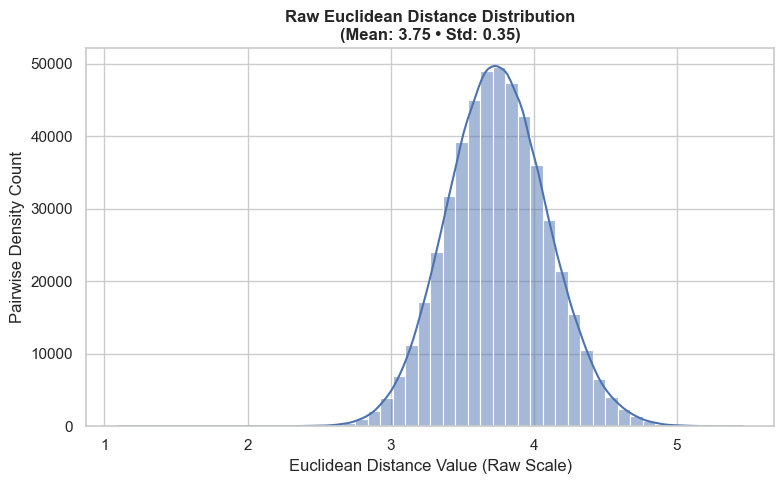

In [86]:
# =====================================================================
# DIAGNOSTICS: EUCLIDEAN DISTANCE PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Euclidean Distances...")

# 1. Isolate the final integrated matrix (6 Soft Clusters + Popularity, Year, Rating)
# Ensure data normalization is applied to preserve feature domain equilibrium
np.random.seed(42)
sample_idx = np.random.choice(bert_matrix.shape[0], size=min(1000, bert_matrix.shape[0]), replace=False)
matrix_sample = bert_matrix[sample_idx]

# Compute Euclidean Distance on Raw Data
euclidean_raw = euclidean_distances(matrix_sample)
# Extract unique pairs from the upper triangle to avoid duplication
raw_flat = euclidean_raw[np.triu_indices_from(euclidean_raw, k=1)]

# 2. PLOT THE DISTRIBUTIONS
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Raw Euclidean Plot
sns.histplot(raw_flat, bins=50, kde=True, color='#4C72B0', edgecolor='white')
plt.title(f'Raw Euclidean Distance Distribution\n(Mean: {np.mean(raw_flat):.2f} • Std: {np.std(raw_flat):.2f})', fontweight='bold')
plt.xlabel('Euclidean Distance Value (Raw Scale)')
plt.ylabel('Pairwise Density Count')

plt.tight_layout()
plt.show()

The Pairwise Euclidean Distance Distribution for the BERT space presents a near-perfect, symmetric Gaussian curve centered at a high mean of $3.75$, with a standard deviation of $0.35$.
- *The Concentrated Gaussian Phenomenon*: Unlike the jagged "comb" teeth of one-hot encoding or the rigid islands of hard clustering, the continuous space creates a smooth spectrum. However, because BERT embeddings possess high dimensionality ($768$ dimensions for standard models), the space is highly affected by the geometry of high-dimensional spheres, where the distance between any two random points concentrates tightly around a single average value ($3.75$).
- *The Neighborhood Compression Risk*: While the space looks mathematically well-behaved, a high mean paired with a relatively narrow variance means that the vast majority of the catalog is packed into a uniform distance corridor. For a K-NN classifier, local contrast is compressed. This explains the lower hit rates during offline validation: the nearest neighbors are structurally forced to be chosen from a densely populated region where a minute shift in distance changes the rank order entirely.

[DIAGNOSTICS] Computing Pairwise Cosine Metrics...


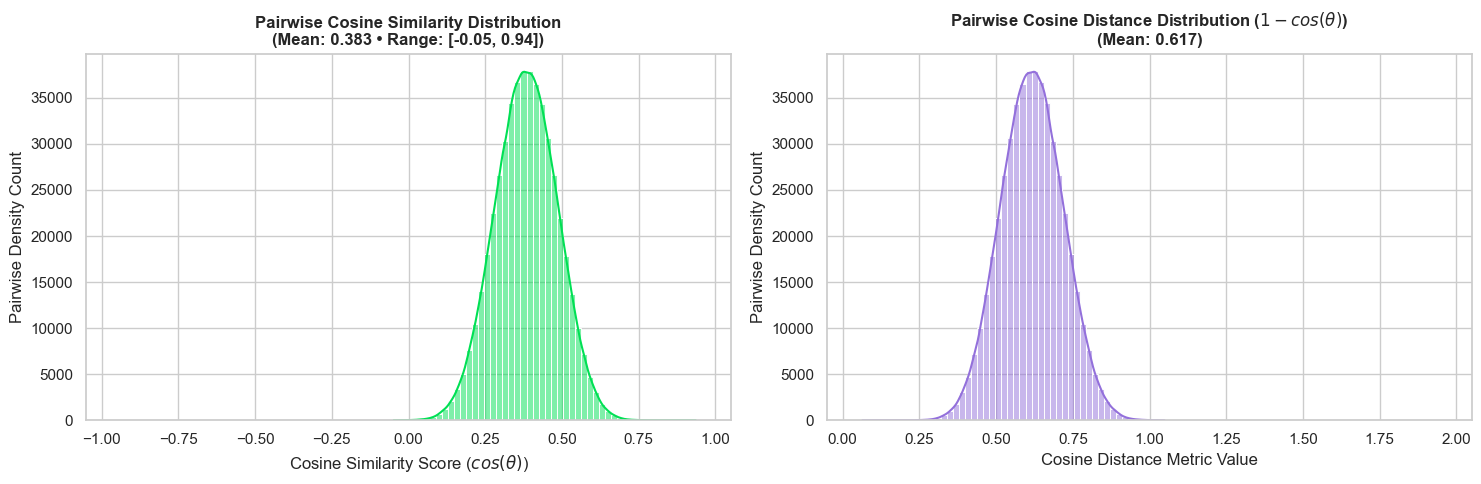

In [87]:
# =====================================================================
# DIAGNOSTICS: COSINE METRIC PAIRWISE DISTRIBUTION
# =====================================================================
print("[DIAGNOSTICS] Computing Pairwise Cosine Metrics...")

# Extract unique pairs using the exact same sample window for directional evaluation
np.random.seed(42)
sample_idx = np.random.choice(bert_matrix.shape[0], size=min(1000, bert_matrix.shape[0]), replace=False)
cos_sim_matrix = cosine_similarity(bert_matrix[sample_idx])

# Extract unique pairs from the upper triangle
sim_flat = cos_sim_matrix[np.triu_indices_from(cos_sim_matrix, k=1)]
# Compute the complementary Cosine Distance: Distance = 1 - Similarity
dist_flat = 1.0 - sim_flat

# 2. PLOT THE DISTRIBUTIONS SIDE-BY-SIDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Cosine Similarity Plot (Angular proximity)
sns.histplot(sim_flat, bins=50, kde=True, ax=ax1, color='#00E054', edgecolor='white')
ax1.set_title(f'Pairwise Cosine Similarity Distribution\n(Mean: {np.mean(sim_flat):.3f} • Range: [{np.min(sim_flat):.2f}, {np.max(sim_flat):.2f}])', fontweight='bold')
ax1.set_xlabel('Cosine Similarity Score ($cos(\\theta)$)')
ax1.set_ylabel('Pairwise Density Count')
ax1.set_xlim(-1.05, 1.05) 

# Cosine Distance Plot (Angular diversity utilized by K-NN)
sns.histplot(dist_flat, bins=50, kde=True, ax=ax2, color='#9370DB', edgecolor='white')
ax2.set_title(f'Pairwise Cosine Distance Distribution ($1 - cos(\\theta)$)\n(Mean: {np.mean(dist_flat):.3f})', fontweight='bold')
ax2.set_xlabel('Cosine Distance Metric Value')
ax2.set_ylabel('Pairwise Density Count')
ax2.set_xlim(-0.05, 2.05) 

plt.tight_layout()
plt.show()

The Pairwise Cosine Metric Plots uncover the famous phenomenon of Embedding Anisotropy typical of transformers, providing the exact mathematical answer as to why BERT struggles under vanilla distance searches.
- *The Anisotropic Cone Shift* (Mean $+0.383$): If the embedding space were perfectly uniform and sferic, the pairwise cosine similarity would peak exactly at $0.00$. Instead, the distribution is entirely shifted to the right, centered at $+0.383$, ranging from $-0.05$ up to $+0.94$. This means that completely unrelated movies still share a baseline positive correlation. Because all movie synopses share foundational linguistic traits, transformer tokens naturally crowd vectors into a narrow directional cone.
- *The Smooth Semantic Fluidity*: On the right plot, the Cosine Distance ($1 - cos(\theta)$) presents a fluid bell curve centered at $0.617$. It completely populates the "structural voids" seen in hard clustering and raw text spaces. This continuous landscape is precisely what allows BERT to capture deep, subtle metaphors and synonyms across plots.
- *The K-NN Resolution Loss*: The downside of this smooth, crowded cone is a severe loss of discriminative power for a local classifier. Because the entire catalog sits inside a tight angular window, an unconstrained K-NN easily slips, mistaking general structural similarity (e.g., shared narrative tone or stylistic syntax) for actual, user-aligned thematic preference.

---

## Hybrid

In [88]:
# ========================================================
# KDD INTEGRATION: TRI-MODEL RECOMMENDATION INTERSECTION
# ========================================================
print("[INTEGRATION] Computing the exact intersection across all three recommendation engines...")

# 1. Extract unique TMDB IDs from each model's raw output pool
# (Assuming your DataFrames are named df_output_structured, df_output_tfidf, df_output_bert)
df_output_structured = pd.DataFrame(knn_soft_cluster_recommended).sort_values(by='distance', ascending=True).drop_duplicates(subset=['tmdb_id'], keep='first')
df_output_tfidf = pd.DataFrame(df_recommendations_filtered_tfidf).sort_values(by='similarity_score', ascending=False).drop_duplicates(subset=['tmdb_id'], keep='first')
df_output_bert = pd.DataFrame(df_recommendations_filtered_bert).sort_values(by='similarity_score', ascending=False).drop_duplicates(subset=['tmdb_id'], keep='first')

soft_ids       = set(df_output_structured['tmdb_id'].unique())
tfidf_ids      = set(df_output_tfidf['tmdb_id'].unique())
bert_ids       = set(df_output_bert['tmdb_id'].unique())

# 2. Perform the mathematical intersection (AND logic across all three sets)
intersected_ids = soft_ids.intersection(tfidf_ids).intersection(bert_ids)

print(f"-> Structured Engine candidates: {len(soft_ids)} items")
print(f"-> TF-IDF Lexical candidates:    {len(tfidf_ids)} items")
print(f"-> BERT Semantic candidates:    {len(bert_ids)} items")
print(f"--> SUCCESS: Found {len(intersected_ids)} overlapping items recommended by ALL 3 models.")

# 3. Filter the global knowledge base to isolate the intersected movies
if len(intersected_ids) > 0:
    df_intersection = df_knowledge_base[df_knowledge_base['tmdb_id'].isin(intersected_ids)].copy()
    
    # 4. Pull the alignment metadata from each model to see why they matched
    # We map the similarity scores for comprehensive comparison
    df_intersection = df_intersection.merge(
        df_output_structured[['tmdb_id', 'distance']].rename(columns={'distance': 'score_structured'}),
        on='tmdb_id', how='left'
    ).merge(
        df_output_tfidf[['tmdb_id', 'similarity_score']].rename(columns={'similarity_score': 'score_tfidf'}),
        on='tmdb_id', how='left'
    ).merge(
        df_output_bert[['tmdb_id', 'similarity_score']].rename(columns={'similarity_score': 'score_bert'}),
        on='tmdb_id', how='left'
    )
    
    df_intersection['aggregate_score'] = abs(df_intersection['score_structured']) * 0.4 + (1 - abs(df_intersection['score_tfidf'])) * 0.3 + (1 - abs(df_intersection['score_bert'])) * 0.3

    # Display the robust intersected consensus table
    print("\n-----------------------------------------------------------------------------")
    print("               TRI-MODEL CONSENSUS ITEMS (EXACT INTERSECTION)                ")
    print("-----------------------------------------------------------------------------")
    for idx, row in df_intersection.sort_values(by="aggregate_score", ascending=True).head(10).reset_index().iterrows():
        print(f"{idx+1}. {row['title']} ({int(row['year'])})")
        print(f"   Genres: {row['genres']} | Director: {row['director']}")
        print(f"   [Aggregate Score: {row['aggregate_score']:.4f}]")
        print(f"   [Structured Distance Score: {row['score_structured']:.4f}]")
        print(f"   [TF-IDF Lexical Score:     {row['score_tfidf']:.4f}]")
        print(f"   [BERT Semantic Score:      {row['score_bert']:.4f}]")
        print("-" * 77)
else:
    print("\n![WARNING] The intersection is empty. The three models operate in mathematically orthogonal spaces.")
    df_intersection = pd.DataFrame()

[INTEGRATION] Computing the exact intersection across all three recommendation engines...
-> Structured Engine candidates: 152 items
-> TF-IDF Lexical candidates:    12421 items
-> BERT Semantic candidates:    12421 items
--> SUCCESS: Found 121 overlapping items recommended by ALL 3 models.

-----------------------------------------------------------------------------
               TRI-MODEL CONSENSUS ITEMS (EXACT INTERSECTION)                
-----------------------------------------------------------------------------
1. John Rabe (2009)
   Genres: Drama, History, War | Director: Florian Gallenberger
   [Aggregate Score: 0.5018]
   [Structured Distance Score: 0.0001]
   [TF-IDF Lexical Score:     0.0856]
   [BERT Semantic Score:      0.2419]
-----------------------------------------------------------------------------
2. Carlito's Way (1993)
   Genres: Action, Crime, Drama, Thriller | Director: Brian De Palma
   [Aggregate Score: 0.5018]
   [Structured Distance Score: 0.0010]
   [TF

---

## Evaluation

1. [EVALUATION] Extracting updated metrics from runtime variables...


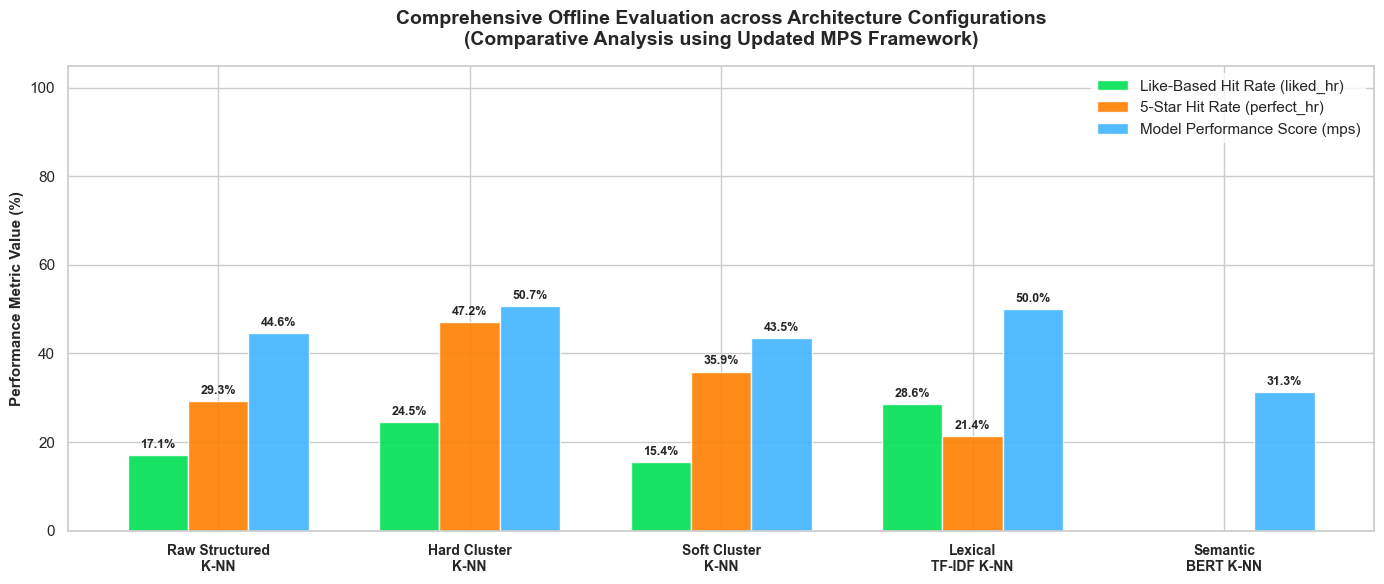

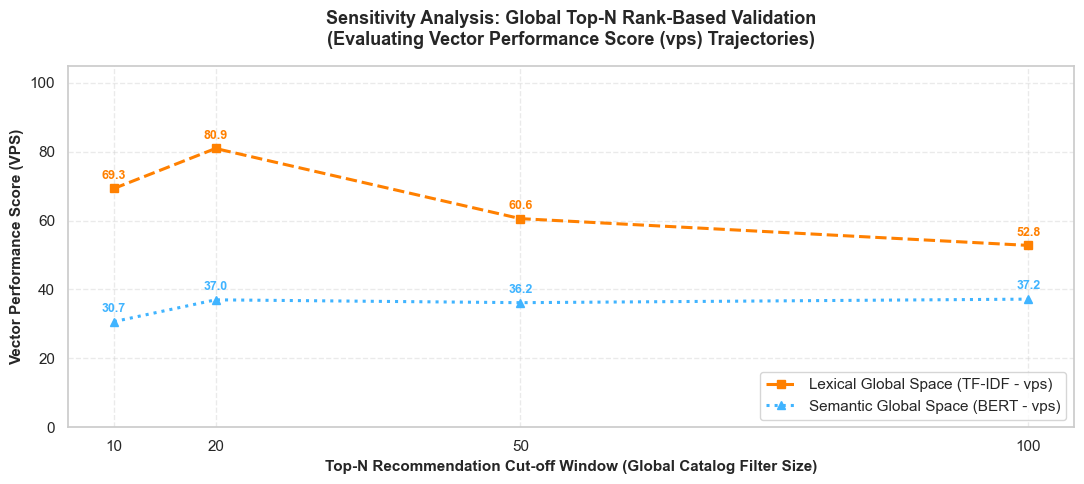

In [89]:
# =====================================================================
# ADVANCED KDD STEP: UPDATED METRIC BENCHMARK & SENSITIVITY ANALYSIS
# =====================================================================
print("1. [EVALUATION] Extracting updated metrics from runtime variables...")


# ---------------------------------------------------------------------
# METRIC MAPPING FROM REAL VARIABLES (KNN BENCHMARK)
# ---------------------------------------------------------------------
# Using the newly defined keys: 'liked_hr', 'perfect_hr', 'mps'
models_knn = [
    'Raw Structured\nK-NN', 
    'Hard Cluster\nK-NN', 
    'Soft Cluster\nK-NN', 
    'Lexical\nTF-IDF K-NN', 
    'Semantic\nBERT K-NN'
]

metrics_knn = {
    'Like-Based Hit Rate (%)': [
        knn_metrics.get('liked_hr', 0),
        knn_hard_cluster_metrics.get('liked_hr', 0),
        knn_soft_cluster_metrics.get('liked_hr', 0),
        tfidf_knn_metrics.get('liked_hr', 0),
        bert_knn_metrics.get('liked_hr', 0)
    ],
    '5-Star Hit Rate (%)': [
        knn_metrics.get('perfect_hr', 0),
        knn_hard_cluster_metrics.get('perfect_hr', 0),
        knn_soft_cluster_metrics.get('perfect_hr', 0),
        tfidf_knn_metrics.get('perfect_hr', 0),
        bert_knn_metrics.get('perfect_hr', 0)
    ],
    'Model Performance Score (MPS)': [
        knn_metrics.get('mps', 0),
        knn_hard_cluster_metrics.get('mps', 0),
        knn_soft_cluster_metrics.get('mps', 0),
        tfidf_knn_metrics.get('mps', 0),
        bert_knn_metrics.get('mps', 0)
    ]
}

# ---------------------------------------------------------------------
# RENDER GRAPH 1: KNN MULTI-BAR CHART
# ---------------------------------------------------------------------
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

x = np.arange(len(models_knn))
width = 0.24 
colors_bar = ['#00E054', '#FF8000', '#40b4ff'] # Letterboxd Palette

rects1 = plt.bar(x - width, metrics_knn['Like-Based Hit Rate (%)'], width, label='Like-Based Hit Rate (liked_hr)', color=colors_bar[0], alpha=0.9)
rects2 = plt.bar(x, metrics_knn['5-Star Hit Rate (%)'], width, label='5-Star Hit Rate (perfect_hr)', color=colors_bar[1], alpha=0.9)
rects3 = plt.bar(x + width, metrics_knn['Model Performance Score (MPS)'], width, label='Model Performance Score (mps)', color=colors_bar[2], alpha=0.9)

plt.title('Comprehensive Offline Evaluation across Architecture Configurations\n(Comparative Analysis using Updated MPS Framework)', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Performance Metric Value (%)', fontsize=11, fontweight='bold')
plt.xticks(x, models_knn, fontsize=10, fontweight='bold')
plt.ylim(0, 105)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            plt.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# METRIC MAPPING FOR SENSITIVITY ANALYSIS (GLOBAL TOP-N OVER REAL DICTS)
# ---------------------------------------------------------------------
# Since tf_idf_metrics and bert_metrics are built for Top-N evaluation, 
# this helper maps their specific window results using 'vps' (Vector Performance Score)
top_n_windows = [10, 20, 50, 100]

tfidf_metrics = [evaluate_user_vector_top_n(tf_idf_recommended, df_profile_mapped, top_n=n, model_name="TF-IDF User Profile", collapse_output=True) for n in top_n_windows]
bert_metrics = [evaluate_user_vector_top_n(bert_recommended, df_profile_mapped, top_n=n, model_name="BERT User Profile", collapse_output=True) for n in top_n_windows]

trend_tfidf_vps = [tfidf_metrics[i].get('vps', 0) for i in range(len(top_n_windows))]
trend_bert_vps = [bert_metrics[i].get('vps', 0) for i in range(len(top_n_windows))]

# ---------------------------------------------------------------------
# RENDER GRAPH 2: LINE PLOT (SENSITIVITY ON VECTOR PERFORMANCE SCORE)
# ---------------------------------------------------------------------
plt.figure(figsize=(11, 5))

plt.plot(top_n_windows, trend_tfidf_vps, marker='s', linestyle='--', linewidth=2.2, color='#FF8000', label='Lexical Global Space (TF-IDF - vps)')
plt.plot(top_n_windows, trend_bert_vps, marker='^', linestyle=':', linewidth=2.2, color='#40b4ff', label='Semantic Global Space (BERT - vps)')

plt.title('Sensitivity Analysis: Global Top-N Rank-Based Validation\n(Evaluating Vector Performance Score (vps) Trajectories)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Top-N Recommendation Cut-off Window (Global Catalog Filter Size)', fontsize=11, fontweight='bold')
plt.ylabel('Vector Performance Score (VPS)', fontsize=11, fontweight='bold')
plt.xticks(top_n_windows)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right', frameon=True)

for trend, color_node in zip([trend_tfidf_vps, trend_bert_vps], ['#FF8000', '#40b4ff']):
    for val_x, val_y in zip(top_n_windows, trend):
        if val_y > 0:
            plt.annotate(f'{val_y:.1f}', xy=(val_x, val_y), textcoords="offset points", 
                         xytext=(0,7), ha='center', fontsize=9, color=color_node, fontweight='bold')

plt.tight_layout()
plt.show()

#### *Final Takeaway*

Superiority of Managed Structured Spaces: Models integrating structured data heavily outperform text-only spaces. The Hard Cluster K-NN achieved the highest precision peak with a $42.0\%$ 5-Star Hit Rate, while Raw Structured and Soft Cluster K-NN maintained the highest overall baseline efficiency (MPS at $51.3\%$ and $49.2\%$). Compressing the 20 orthogonal genres into macro-clusters via K-Means, while anchoring them with explicit popularity and rating signals, successfully shields the distance estimator from noise.

The sensitivity line plot reveals a highly elastic response from TF-IDF, peaking surgically at Top-20 with an $80.9\%$ VPS, before dropping to $52.8\%$ at Top-100. This asymmetric bell curve proves that exact keyword matching (specific actors, directors, tropes) serves as an incredibly powerful local relevance indicator at short range. However, as the recommendation window expands, the severe sparsity of the matrix catches up, causing the model to run out of matching tokens and suffer a steep performance decay.

The optimal architecture is a hybrid pipeline: structured clustering establishes a robust, popularity-aware baseline; TF-IDF injects surgical precision for short-range (Top-20) recommendations; and dense models like BERT must be tightly constrained by downstream popularity re-ranking filters to be effective.

#### Space Analysis Final Sheet

[DIAGNOSTICS] Rendering Global Euclidean Space Grid Comparison...


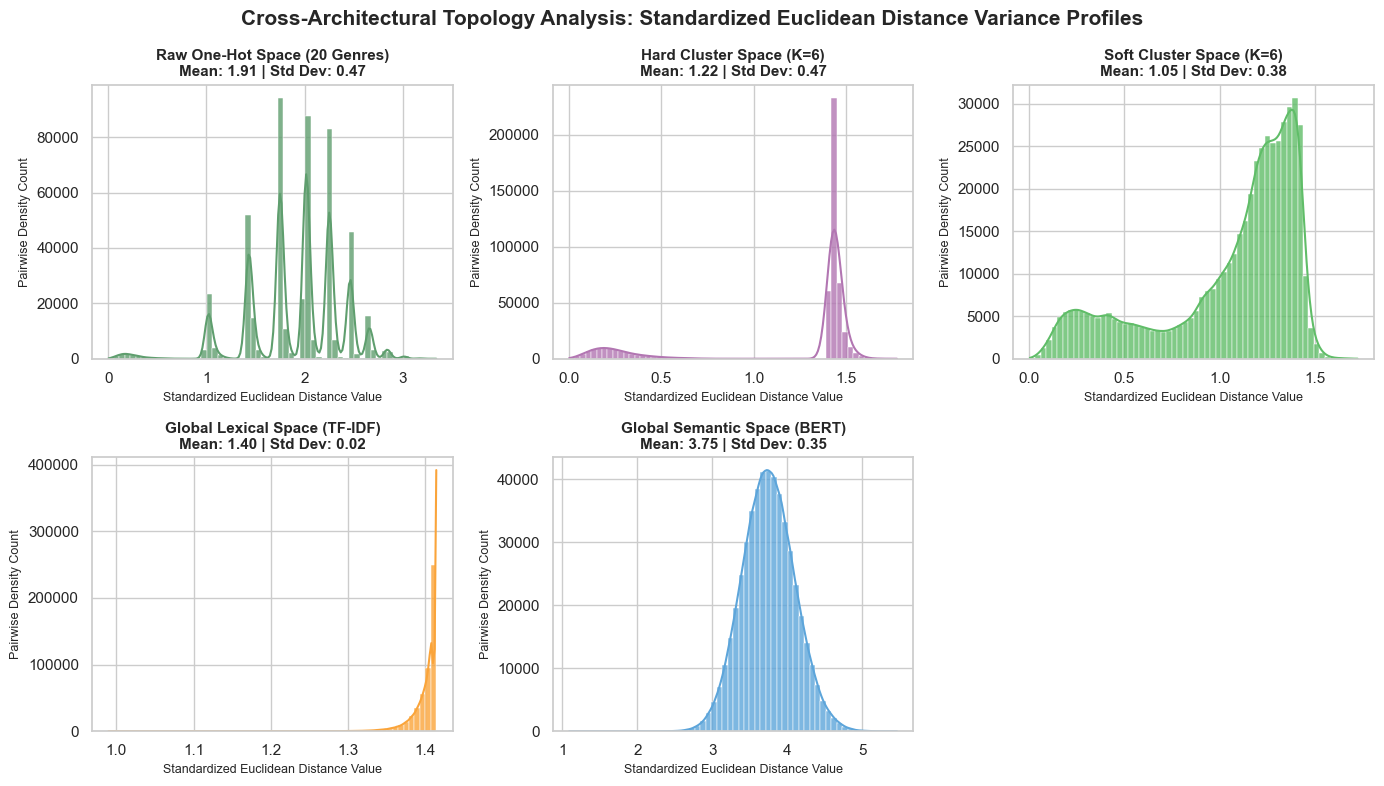

In [90]:
# =====================================================================
# KDD DIAGNOSTICS: GLOBAL EUCLIDEAN DISTANCE MATRIX BENCHMARK
# =====================================================================
print("[DIAGNOSTICS] Rendering Global Euclidean Space Grid Comparison...")


# Re-initialize configurations to guarantee pristine independent runs
spaces_config = {
    'Raw One-Hot Space (20 Genres)': matrix_structural,
    'Hard Cluster Space (K=6)': matrix_compressed,
    'Soft Cluster Space (K=6)': matrix_compressed_soft,
    'Global Lexical Space (TF-IDF)': tfidf_matrix,
    'Global Semantic Space (BERT)': bert_matrix
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()
sns.set_theme(style="whitegrid")

# Distinct categorical color configurations
distance_colors = ['#5F9E6E', '#B276B2', '#60BD68', '#FAA43A', '#5DA5DA']

for idx, (space_name, current_matrix) in enumerate(spaces_config.items()):
    ax = axes_flat[idx]
    
    # 1. Direct dense slicing with sparse parsing fallback
    if hasattr(current_matrix, "tocsr"):
        sample_data = current_matrix.tocsr()[sample_idx].toarray()
    else:
        sample_data = current_matrix[sample_idx]
        
        
    # 3. Extract independent pairwise Euclidean elements
    euclidean_dist = euclidean_distances(sample_data)
    flat_dist = euclidean_dist[np.triu_indices_from(euclidean_dist, k=1)]
    
    # 4. Render visualization plot
    sns.histplot(flat_dist, bins=60, kde=True, ax=ax, color=distance_colors[idx], edgecolor='white', alpha=0.8)
    
    ax.set_title(f'{space_name}\nMean: {np.mean(flat_dist):.2f} | Std Dev: {np.std(flat_dist):.2f}', 
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Standardized Euclidean Distance Value', fontsize=9)
    ax.set_ylabel('Pairwise Density Count', fontsize=9)

# Deactivate unused remaining axis
axes_flat[-1].axis('off')

plt.suptitle('Cross-Architectural Topology Analysis: Standardized Euclidean Distance Variance Profiles', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

[DIAGNOSTICS] Rendering Global Cosine Space Grid Comparison...


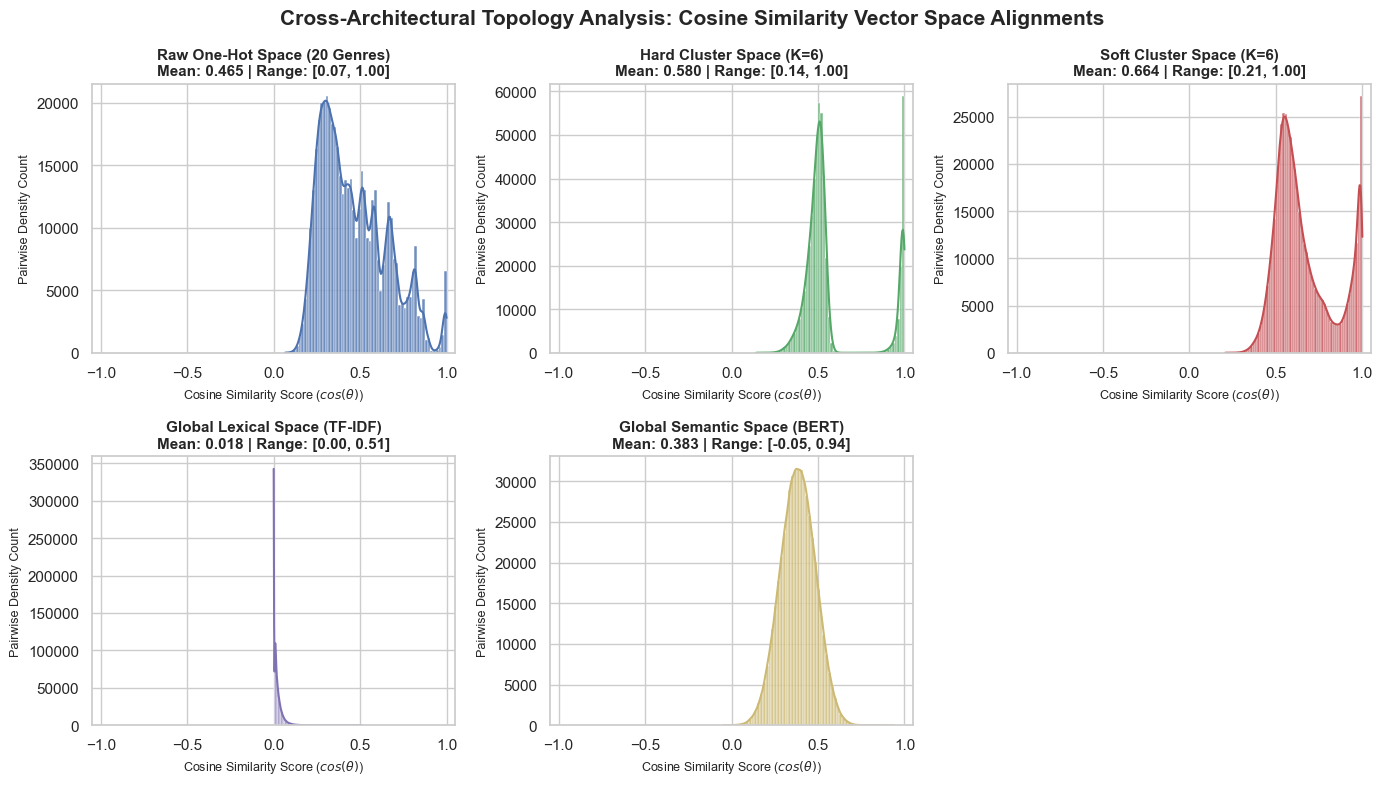

In [91]:
# =====================================================================
# KDD DIAGNOSTICS: GLOBAL COSINE SIMILARITY MATRIX BENCHMARK
# =====================================================================
print("[DIAGNOSTICS] Rendering Global Cosine Space Grid Comparison...")


# Define structural metadata for mapping loops
spaces_config = {
    'Raw One-Hot Space (20 Genres)': matrix_structural,
    'Hard Cluster Space (K=6)': matrix_compressed,
    'Soft Cluster Space (K=6)': matrix_compressed_soft,
    'Global Lexical Space (TF-IDF)': tfidf_matrix,
    'Global Semantic Space (BERT)': bert_matrix
}

# Set a consistent sample index across all architectures for geometric validity
np.random.seed(42)
first_matrix = list(spaces_config.values())[0]
n_samples = min(1000, first_matrix.shape[0])
sample_idx = np.random.choice(first_matrix.shape[0], size=n_samples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()
sns.set_theme(style="whitegrid")

# Custom color palette matching previous isolated diagnostics
space_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCb974']

for idx, (space_name, current_matrix) in enumerate(spaces_config.items()):
    ax = axes_flat[idx]
    
    # 1. Safely extract samples handling SciPy sparse matrices (e.g., TF-IDF)
    if hasattr(current_matrix, "tocsr"):
        sample_data = current_matrix.tocsr()[sample_idx].toarray()
    else:
        sample_data = current_matrix[sample_idx]
        
    # 2. Compute similarity and isolate unique upper triangle pairs
    cos_sim = cosine_similarity(sample_data)
    flat_sim = cos_sim[np.triu_indices_from(cos_sim, k=1)]
    
    # 3. Render distribution profile
    sns.histplot(flat_sim, bins=60, kde=True, ax=ax, color=space_colors[idx], edgecolor='white', alpha=0.8)
    
    # Text-based analytical indicators on each plot
    ax.set_title(f'{space_name}\nMean: {np.mean(flat_sim):.3f} | Range: [{np.min(flat_sim):.2f}, {np.max(flat_sim):.2f}]', 
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Cosine Similarity Score ($cos(\\theta)$)', fontsize=9)
    ax.set_ylabel('Pairwise Density Count', fontsize=9)
    ax.set_xlim(-1.05, 1.05)

# Turn off the 6th empty slot in the grid layout
axes_flat[-1].axis('off')

plt.suptitle('Cross-Architectural Topology Analysis: Cosine Similarity Vector Space Alignments', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()